# 04. EDA

## 4.1 Цель и задачи EDA

### Цель
Исследовать распределения характеристик заказов и определить факторы, связанные с появлением негативного отзыва (`bad_review`), а также выявить особенности данных, которые необходимо учитывать при дальнейшей подготовке признаков и построении модели.

### Основные вопросы этапа:

- Как меняется количество заказов во времени?
- Как устроены стоимость, размер и состав заказа?
- Как устроен процесс доставки?
- Насколько часто заказы опаздывают?
- Какие способы оплаты используются?
- Есть ли географические различия между заказами?
- Какие характеристики сильнее всего связаны с bad_review?
- Есть ли сильные выбросы и сильно скошенные признаки?
- Какие признаки дублируют друг друга?
- Какие признаки нельзя использовать в модели из-за утечки информации.

## Вспомогательные функции

In [1]:
def compare_by_bad_review(df, column):
    result = (
        df.groupby("bad_review")[column]
        .agg(
            count="count",
            mean="mean",
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75)
        )
    )

    return result

## 4.2 Загрузка аналитической таблицы и контроль структуры

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
orders_analytics = pd.read_csv("../data/processed/orders_analytics.csv", parse_dates=["order_purchase_timestamp",
                                                                     "order_approved_at",
                                                                     "order_delivered_carrier_date",
                                                                     "order_delivered_customer_date",
                                                                     "order_estimated_delivery_date",
                                                                     "review_creation_date", 
                                                                     "review_answer_timestamp"])

In [4]:
#размер orders_analytics
orders_analytics.shape

(99441, 64)

In [5]:
orders_analytics["order_id"].is_unique

True

In [6]:
orders_analytics[["order_purchase_timestamp", 
                  "order_approved_at", 
                  "order_delivered_carrier_date", 
                  "order_delivered_customer_date",
                  "order_estimated_delivery_date",
                  "review_creation_date", 
                  "review_answer_timestamp"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[us]
 1   order_approved_at              99281 non-null  datetime64[us]
 2   order_delivered_carrier_date   97658 non-null  datetime64[us]
 3   order_delivered_customer_date  96476 non-null  datetime64[us]
 4   order_estimated_delivery_date  99441 non-null  datetime64[us]
 5   review_creation_date           98673 non-null  datetime64[us]
 6   review_answer_timestamp        98673 non-null  datetime64[us]
dtypes: datetime64[us](7)
memory usage: 5.3 MB


In [7]:
orders_analytics["purchase_year_month"].info()

<class 'pandas.Series'>
RangeIndex: 99441 entries, 0 to 99440
Series name: purchase_year_month
Non-Null Count  Dtype
--------------  -----
99441 non-null  str  
dtypes: str(1)
memory usage: 777.0 KB


In [8]:
orders_analytics["purchase_year_month"].sample(10)

35968    2017-11-30 00:00:00
83810    2018-01-31 00:00:00
73057    2018-01-31 00:00:00
88568    2018-05-31 00:00:00
58397    2017-06-30 00:00:00
96893    2017-08-31 00:00:00
33987    2018-02-28 00:00:00
34258    2018-08-31 00:00:00
19209    2018-03-31 00:00:00
27493    2018-06-30 00:00:00
Name: purchase_year_month, dtype: str

In [9]:
#восстановление типа для purchase_year_month
orders_analytics["purchase_year_month"] = (
    pd.to_datetime(orders_analytics["purchase_year_month"])
    .dt.to_period("M")
)

In [10]:
orders_analytics["purchase_year_month"].dtype

period[M]

In [11]:
orders_analytics["purchase_year_month"].sample(10)

44364    2018-08
73192    2018-04
18087    2017-07
19703    2017-05
50980    2018-04
72846    2018-06
25345    2017-03
62161    2018-02
37933    2017-08
32191    2018-06
Name: purchase_year_month, dtype: period[M]

In [12]:
#контрольная проверка пропусков после загрузки
missing_values = orders_analytics.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

carrier_handoff_time_days        3156
delivery_time_days               2965
order_delivered_customer_date    2965
delay_days                       2965
early_delivery_days              2965
delivery_delay_days              2965
is_late_delivery                 2965
order_delivered_carrier_date     1783
total_weight_g                    791
total_volume_cm3                  791
abs_payment_difference            776
payment_difference                776
unknown_category_items            775
items_count                       775
products_count                    775
sellers_count                     775
categories_count                  775
has_unknown_category              775
mean_freight                      775
total_price                       775
total_freight                     775
max_item_price                    775
mean_item_price                   775
has_multiple_products             775
order_total                       775
freight_ratio                     775
has_multiple

In [13]:
orders_analytics[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "review_creation_date",
        "review_answer_timestamp"
    ]
].isna().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
review_creation_date              768
review_answer_timestamp           768
dtype: int64

Аналитическая таблица успешно загружена: размер и уникальность `order_id` сохранены, временные признаки имеют корректные типы данных. Количество пропусков соответствует результатам предыдущего этапа, новых пропущенных значений после сохранения и повторного чтения таблицы не возникло.


## 4.3 Формирование аналитических выборок

### 4.3.1. Все заказы

Полная аналитическая выборка `orders_analytics` содержит `99 441` заказ и используется для исследований, не требующих информации о фактической доставке или наличии отзыва.

### 4.3.2. Заказы с фактической доставкой

In [14]:
delivered_orders = orders_analytics[orders_analytics["order_delivered_customer_date"].notna()].copy()

In [15]:
delivered_orders.shape

(96476, 64)

In [16]:
delivered_orders["order_delivered_customer_date"].isna().sum()

np.int64(0)

### 4.3.3. Заказы с отзывами

In [17]:
reviewed_orders = orders_analytics[orders_analytics["bad_review"].notna()].copy()

In [18]:
reviewed_orders.shape

(98673, 64)

In [19]:
reviewed_orders["bad_review"].isna().sum()

np.int64(0)

### 4.3.4. Доставленные заказы с отзывами

In [20]:
delivered_reviewed_orders = orders_analytics[orders_analytics["order_delivered_customer_date"].notna() & orders_analytics["bad_review"].notna()].copy()

In [21]:
delivered_reviewed_orders.shape

(95830, 64)

In [22]:
delivered_reviewed_orders[
    ["order_delivered_customer_date", "bad_review"]
].isna().sum()

order_delivered_customer_date    0
bad_review                       0
dtype: int64

| Выборка | Для чего |
| --- | --- |
| orders_analytics | Общий EDA всех заказов |
| delivered_orders | Анализ фактической доставки и опозданий |
| reviewed_orders | Анализ целевой переменной bad_review |
| delivered_reviewed_orders | Анализ связи доставки с bad_review |

## 4.4 Статусы заказов

In [23]:
#количество заказов каждого статуса
status_counts = (orders_analytics["order_status"].value_counts())
status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [24]:
#доля каждого статуса
orders_analytics["order_status"].value_counts(normalize=True).mul(100)

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [25]:
status_summary = (
    orders_analytics["order_status"]
    .value_counts()
    .rename("orders_count")
    .to_frame()
)

status_summary["share_pct"] = (
    status_summary["orders_count"]
    / len(orders_analytics)
    * 100
)

status_summary["share_pct"] = status_summary["share_pct"].round(2)
status_summary

,orders_count,share_pct
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


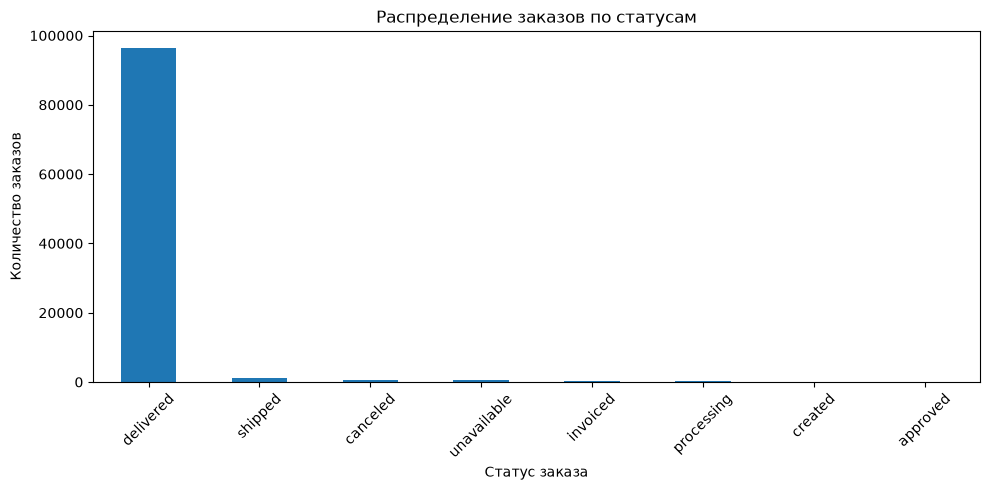

In [26]:
status_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по статусам")
plt.xlabel("Статус заказа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`97%` заказов имеют статус `delivered`, поэтому аналитическая таблица преимущественно описывает завершённые покупки. Остальные статусы составляют небольшую долю выборки. При этом незавершённые и отменённые заказы могут отличаться по пользовательскому опыту, поэтому на этапе EDA они пока сохраняются и будут отдельно сопоставлены с bad_review.

### Связь статуса с bad_review

In [27]:
status_review_summary = (
    reviewed_orders
    .groupby("order_status", as_index=False)
    .agg(
        reviewed_orders_count=("bad_review", "size"), #количество заказов группы
        bad_reviews_count=("bad_review", "sum"), #число плохих отзывов
        bad_review_rate=("bad_review", "mean") #доля плохих отзывов
    )
).sort_values(by="reviewed_orders_count", ascending=False)
status_review_summary["bad_review_rate"] *= 100
status_review_summary["bad_review_rate"] = (
    status_review_summary["bad_review_rate"].round(2)
)
status_review_summary

,order_status,reviewed_orders_count,bad_reviews_count,bad_review_rate
3,delivered,95832,12273.0,12.81
6,shipped,1032,718.0,69.57
1,canceled,605,465.0,76.86
7,unavailable,595,505.0,84.87
4,invoiced,309,256.0,82.85
5,processing,295,274.0,92.88
2,created,3,2.0,66.67
0,approved,2,1.0,50.00


Статус заказа заметно связан с вероятностью негативного отзыва. Среди доставленных заказов доля `bad_review` составляет около `12,8%`, тогда как для незавершённых или проблемных статусов она существенно выше: около 69,6% для shipped, 76,9% для canceled, 84,9% для unavailable и 92,9% для processing. Это показывает, что проблемы с завершением заказа и доставкой тесно связаны с негативным пользовательским опытом. При этом результаты для статусов created и approved следует интерпретировать с осторожностью из-за крайне малого числа наблюдений.

С учётом того, что около `97%` всех заказов имеют статус `delivered`, дальнейший анализ основной выборки будет в значительной степени отражать поведение завершённых заказов.

## 4.5 Временная динамика заказов

### 4.5.1. Количество заказов по месяцам

In [28]:
num_of_orders_by_month = (
    orders_analytics.groupby("purchase_year_month")
    .agg(num_of_orders=("order_id", "size"))
)
num_of_orders_by_month

,num_of_orders
purchase_year_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


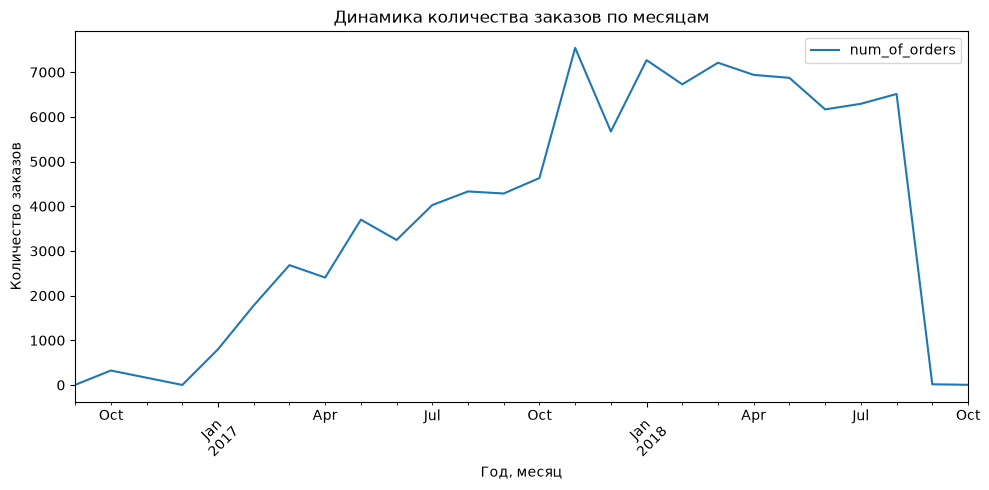

In [29]:
num_of_orders_by_month.plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Динамика количества заказов по месяцам")
plt.xlabel("Год, месяц")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В течение основной части наблюдаемого периода количество заказов демонстрирует выраженный рост. В `2017 году` число заказов увеличивается от `800` в январе до максимума около `7,5 тыс.` в ноябре. В `2018 году` объём заказов остаётся относительно высоким и в основном находится на уровне `6–7 тыс.` заказов в месяц. Крайние месяцы периода (2016-09, 2016-10, 2016-12 и 2018-09) содержат существенно меньше наблюдений и, вероятно, представлены неполными данными, поэтому их не следует напрямую сравнивать с полноценными месяцами.

### 4.5.2. Заказы по дням недели

In [30]:
orders_by_day_of_week = (
    orders_analytics.groupby("purchase_day_of_week")
    .agg(num_of_orders=("order_id", "size"))
)

orders_by_day_of_week["share_pct"] = (
    orders_by_day_of_week["num_of_orders"]
    / len(orders_analytics)
    * 100
)

orders_by_day_of_week["share_pct"] = (
    orders_by_day_of_week["share_pct"].round(2)
)

orders_by_day_of_week.index = ["понедельник", "вторник", "среда", "четверг", "пятница", "суббота", "воскресенье"]

orders_by_day_of_week

,num_of_orders,share_pct
понедельник,16196,16.29
вторник,15963,16.05
среда,15552,15.64
четверг,14761,14.84
пятница,14122,14.20
суббота,10887,10.95
воскресенье,11960,12.03


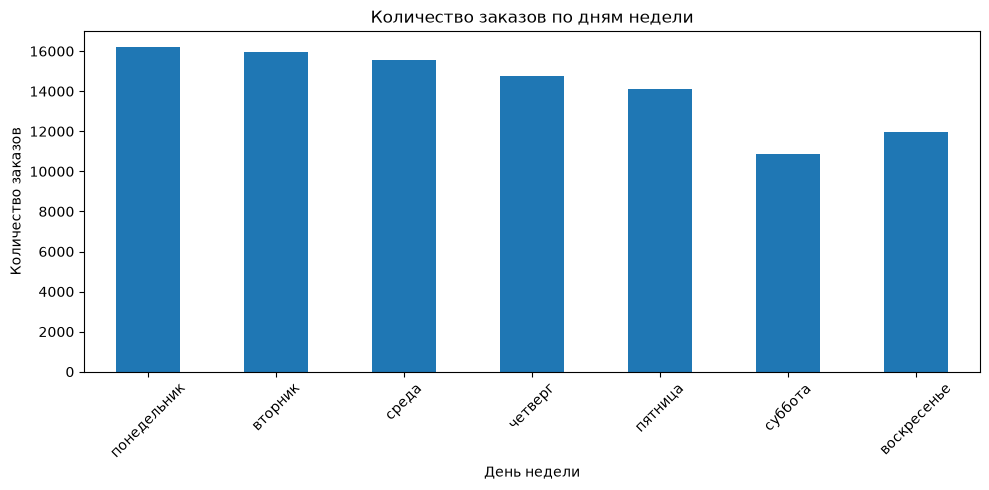

In [31]:
orders_by_day_of_week["num_of_orders"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Количество заказов по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Заказы распределены по дням недели неравномерно. Наибольшая доля заказов приходится на понедельник (16,29%), вторник (16,05%) и среду (15,64%). В течение рабочей недели количество заказов постепенно снижается, а минимальная активность наблюдается в субботу — 10,95% заказов. В воскресенье доля заказов немного увеличивается до 12,03%. Таким образом, покупательская активность выше в начале рабочей недели и ниже в выходные дни.

### 4.5.3. Заказы по часам

In [32]:
orders_by_hours = (
    orders_analytics.groupby("purchase_hour")
    .agg(num_of_orders=("order_id", "size"))
)

orders_by_hours["share_pct"] = (
    orders_by_hours["num_of_orders"]
    / len(orders_analytics)
    * 100
)

orders_by_hours["share_pct"] = (
    orders_by_hours["share_pct"].round(2)
)

orders_by_hours

,num_of_orders,share_pct
purchase_hour,,
0,2394,2.41
1,1170,1.18
2,510,0.51
3,272,0.27
4,206,0.21
5,188,0.19
6,502,0.50
7,1231,1.24
8,2967,2.98


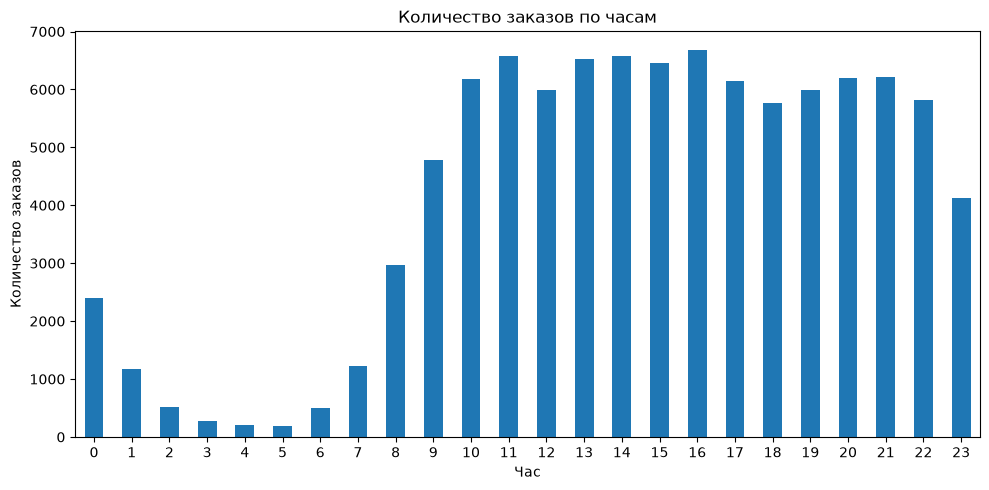

In [33]:
orders_by_hours["num_of_orders"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Количество заказов по часам")
plt.xlabel("Час")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Суточная активность покупателей распределена неравномерно. Минимальное количество заказов наблюдается ночью, особенно в интервале примерно с 3:00 до 5:00. Начиная с утра число заказов быстро растёт и достигает высокого уровня к 10:00. В течение дня и вечера, примерно с 10:00 до 21:00, активность остаётся стабильно высокой, а максимальная доля заказов наблюдается около 16:00 — 6,71%. После 21:00 количество заказов постепенно снижается. Таким образом, основная покупательская активность приходится на дневные и вечерние часы.

### 4.5.4. Будни против выходных

In [34]:
orders_by_weekend = (
    orders_analytics.groupby("purchase_is_weekend")
    .agg(num_of_orders=("order_id", "size"))
)

orders_by_weekend["share_pct"] = (
    orders_by_weekend["num_of_orders"]
    / len(orders_analytics)
    * 100
)

orders_by_weekend["share_pct"] = (
    orders_by_weekend["share_pct"].round(2)
)

orders_by_weekend.index = ["Будни", "Выходные"]

orders_by_weekend

,num_of_orders,share_pct
Будни,76594,77.02
Выходные,22847,22.98


Большинство заказов оформляется в будние дни — `77,02%` от общего числа заказов. На выходные приходится `22,98%` заказов. Это согласуется с распределением по отдельным дням недели: покупательская активность в будни в среднем выше, чем в субботу и воскресенье.

## 4.6 Структура и размер заказа

### 4.6.1. Количество позиций

In [35]:
orders_analytics["items_count"].describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: items_count, dtype: float64

In [36]:
#доля заказов с одной позицией
orders_analytics["items_count"].dropna().eq(1).mean() * 100
#len(orders_analytics[orders_analytics["items_count"] == 1]) / len(orders_analytics)

np.float64(90.06445989499929)

In [37]:
#распределение количества позиций
items_count_distribution = (orders_analytics["items_count"].value_counts().sort_index())
items_count_distribution

items_count
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
11.0        4
12.0        5
13.0        1
14.0        2
15.0        2
20.0        2
21.0        1
Name: count, dtype: int64

In [38]:
#Доля заказов с несколькими позициями
orders_analytics["items_count"].dropna().gt(1).mean() * 100

np.float64(9.93554010500071)

In [39]:
#Верхние процентили
orders_analytics["items_count"].quantile(
    [0.90, 0.95, 0.99]
)

0.90    1.0
0.95    2.0
0.99    3.0
Name: items_count, dtype: float64

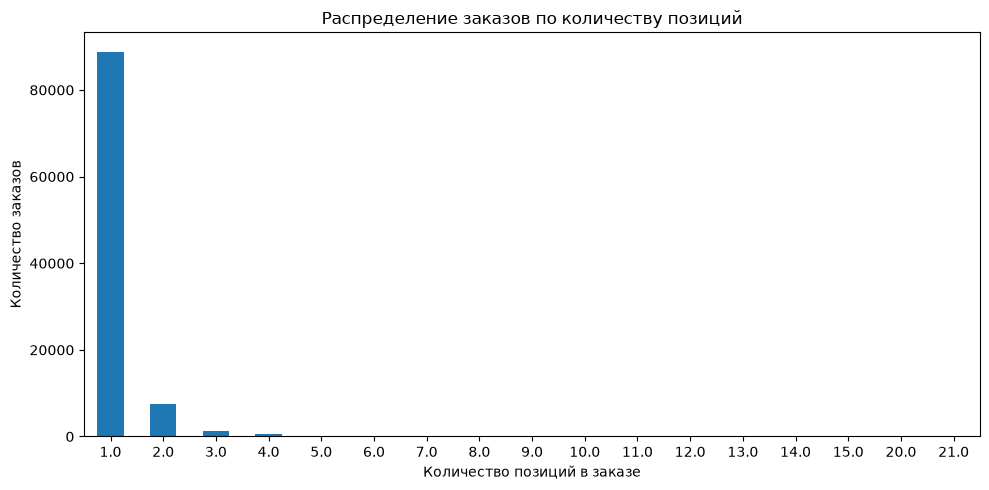

In [40]:
items_count_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по количеству позиций")
plt.xlabel("Количество позиций в заказе")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Структура заказов преимущественно простая: `90,06%` заказов содержат одну позицию, а только 9,94% — несколько. 95% заказов включают не более двух позиций, а 99% — не более трёх. При этом встречаются редкие крупные заказы вплоть до 21 позиции, что формирует длинный правый хвост распределения.

### 4.6.2. Количество уникальных товаров

In [41]:
valid_products = orders_analytics[
    ["items_count", "products_count"]
].dropna()

(
    valid_products["items_count"]
    .eq(valid_products["products_count"])
    .mean()
    * 100
)

np.float64(92.93779012020352)

In [42]:
orders_analytics["products_count"].describe()

count    98666.000000
mean         1.038098
std          0.226456
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: products_count, dtype: float64

In [43]:
#Доля заказов с одним уникальным товаром
orders_analytics["products_count"].dropna().eq(1).mean() * 100

np.float64(96.72024810978452)

In [44]:
#Доля заказов с несколькими уникальными товарами
orders_analytics["products_count"].dropna().gt(1).mean() * 100

np.float64(3.2797518902154743)

In [45]:
#Насколько часто один товар покупают несколькими единицами
(
    valid_products["items_count"]
    .gt(valid_products["products_count"])
    .mean()
    * 100
)

np.float64(7.062209879796486)

In [46]:
#Распределение products_count
products_count_distribution = (
    orders_analytics["products_count"]
    .value_counts()
    .sort_index()
)

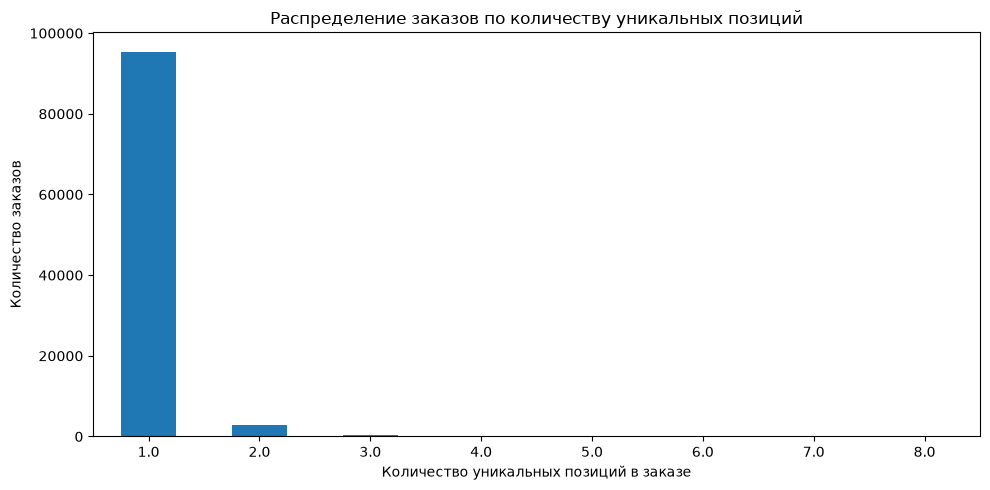

In [47]:
products_count_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по количеству уникальных позиций")
plt.xlabel("Количество уникальных позиций в заказе")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
#проверка
(
    valid_products["products_count"]
    > valid_products["items_count"]
).sum()

np.int64(0)

Большинство заказов содержат только один уникальный товар — около `96,7%`. Заказы с несколькими различными товарами встречаются редко и составляют около 3,3%. При этом примерно в 7,1% заказов количество позиций превышает число уникальных товаров, то есть один и тот же товар покупается в нескольких экземплярах. В целом структура заказов по числу уникальных товаров также сильно смещена в сторону одиночных покупок.

###  4.6.3. Несколько продавцов

In [49]:
#какая доля заказов содержит товары разных продавцов
orders_analytics["has_multiple_sellers"].dropna().eq(1).mean() * 100

np.float64(1.295279022155555)

In [50]:
#какая доля заказов содержит товары только одного продавца
orders_analytics["has_multiple_sellers"].dropna().eq(0).mean() * 100

np.float64(98.70472097784445)

In [51]:
sellers_count_distribution = (orders_analytics["sellers_count"].value_counts().sort_index())
sellers_count_distribution

sellers_count
1.0    97388
2.0     1219
3.0       54
4.0        3
5.0        2
Name: count, dtype: int64

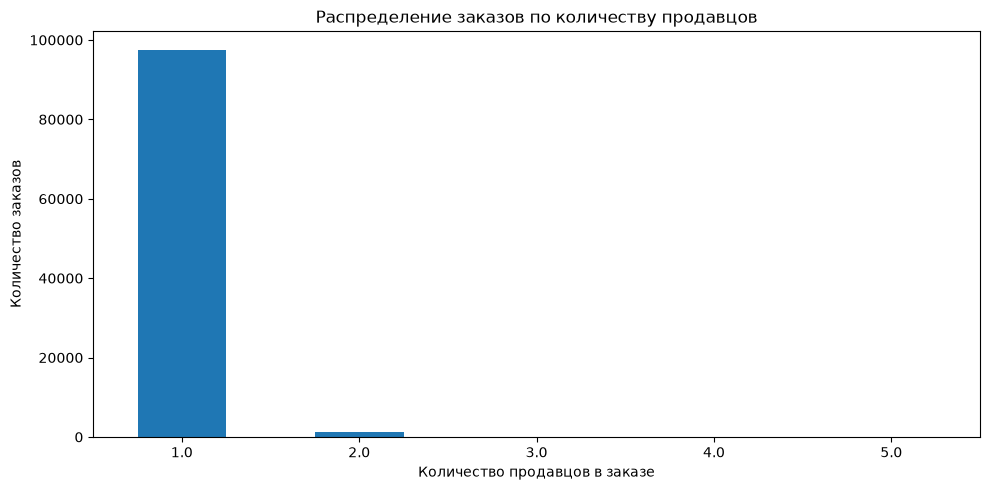

In [52]:
sellers_count_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по количеству продавцов")
plt.xlabel("Количество продавцов в заказе")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
#проверка
(
    orders_analytics["has_multiple_sellers"].dropna()
    != orders_analytics["sellers_count"].dropna().gt(1)
).sum()

np.int64(0)

Подавляющее большинство заказов оформлено у одного продавца — около `98,7%`. Заказы с несколькими продавцами встречаются редко и составляют около 1,3% выборки. Максимальное число продавцов в одном заказе равно 5, при этом случаи с тремя и более продавцами единичны.

### 4.6.4. Количество категорий

In [54]:
#какая доля заказов содержит товары разных категорий
orders_analytics["categories_count"].dropna().gt(1).mean() * 100

np.float64(0.7368293029006953)

In [55]:
#какая доля заказов содержит товары только одной категории
orders_analytics["categories_count"].dropna().eq(1).mean() * 100

np.float64(97.85539091480348)

In [56]:
#какая доля заказов содержит товары с неизвестными категориями во всех товарах
orders_analytics["categories_count"].dropna().eq(0).mean() * 100

np.float64(1.4077797822958265)

In [57]:
categories_count_distribution = (orders_analytics["categories_count"].value_counts().sort_index())
categories_count_distribution

categories_count
0.0     1389
1.0    96550
2.0      712
3.0       15
Name: count, dtype: int64

In [58]:
#проверка: categories_count == 0 действительно означает неизвестные категории у всех позиций
zero_category_orders = orders_analytics[
    orders_analytics["categories_count"].eq(0)
]

(
    zero_category_orders["unknown_category_items"]
    == zero_category_orders["items_count"]
).value_counts()

True    1389
Name: count, dtype: int64

In [59]:
#проверка
valid_categories = orders_analytics[
    ["categories_count", "products_count"]
].dropna()

(
    valid_categories["categories_count"]
    > valid_categories["products_count"]
).sum()

np.int64(0)

In [60]:
#доля заказов с хотя бы одной неизвестной категорией
orders_analytics["has_unknown_category"].dropna().eq(1).mean() * 100

np.float64(1.4706180447165185)

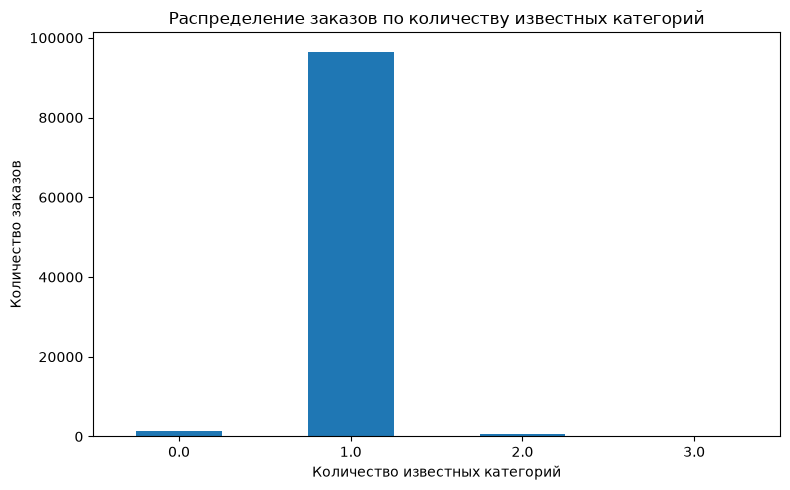

In [61]:
categories_count_distribution = (
    orders_analytics["categories_count"]
    .value_counts()
    .sort_index()
)

categories_count_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Распределение заказов по количеству известных категорий")
plt.xlabel("Количество известных категорий")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Подавляющее большинство заказов содержит товары только одной известной категории — около `97,9%`. Заказы с несколькими известными категориями встречаются редко и составляют менее 1%. Примерно в 1,5% заказов присутствует хотя бы одна товарная позиция с неизвестной категорией, а в 1,4% заказов категории неизвестны у всех позиций. В целом структура заказов по категориям преимущественно однородна.

## 4.7 Стоимость заказа и доставки

### 4.7.1. Стоимость товаров

#### Исследование распределения total_price

In [62]:
orders_analytics["total_price"].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: total_price, dtype: float64

In [63]:
#верхние процентили
orders_analytics["total_price"].quantile([0.90, 0.95, 0.99])

0.90    269.9
0.95    399.9
0.99    998.9
Name: total_price, dtype: float64

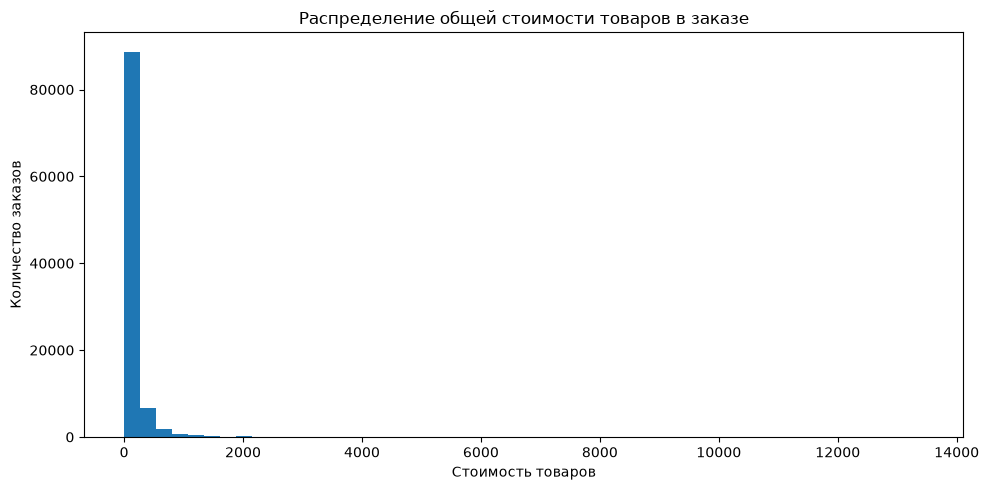

In [64]:
orders_analytics["total_price"].dropna().plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение общей стоимости товаров в заказе")
plt.xlabel("Стоимость товаров")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

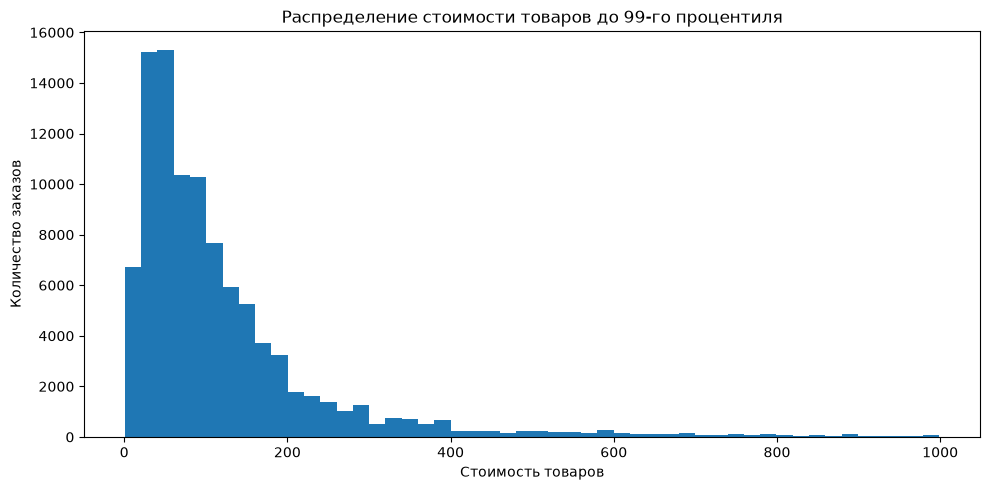

In [65]:
#увеличенный график основной части распределения
price_99 = orders_analytics["total_price"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["total_price"] <= price_99,
    "total_price"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение стоимости товаров до 99-го процентиля")
plt.xlabel("Стоимость товаров")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `total_price` имеет выраженную правостороннюю асимметрию. Медианная стоимость товаров в заказе составляет `86,9`, тогда как среднее значение заметно выше — `137,75`, что связано с наличием небольшого числа дорогих заказов. 90% заказов имеют стоимость товаров не выше 269,9, 95% — не выше 399,9, а 99% — не выше 998,9. При этом максимальная стоимость достигает 13 440, поэтому в данных присутствует длинный правый хвост с редкими высокими значениями.

#### Исследование распределения mean_item_price

In [66]:
orders_analytics["mean_item_price"].describe()

count    98666.000000
mean       125.919255
std        190.985636
min          0.850000
25%         41.990000
50%         79.000000
75%        139.900000
max       6735.000000
Name: mean_item_price, dtype: float64

In [67]:
#верхние процентили
orders_analytics["mean_item_price"].quantile([0.90, 0.95, 0.99])

0.90    239.9000
0.95    369.0000
0.99    899.9935
Name: mean_item_price, dtype: float64

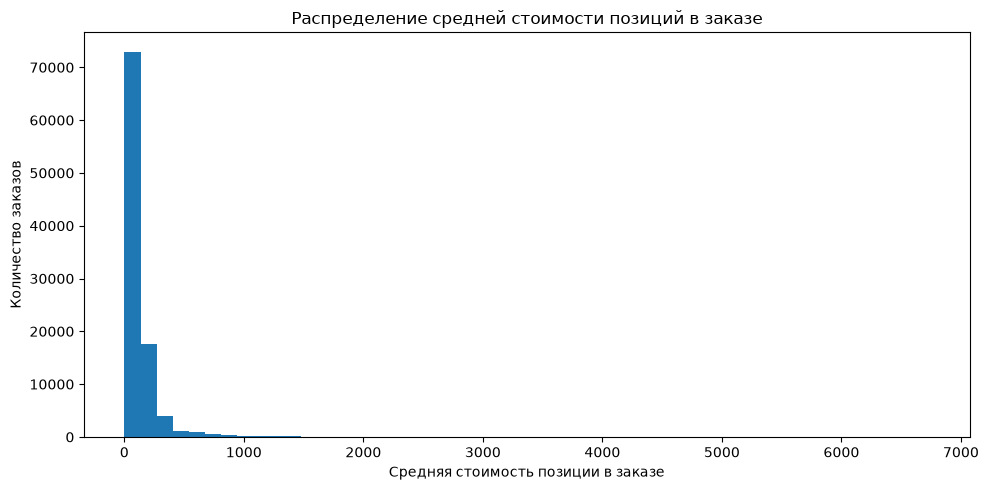

In [68]:
orders_analytics["mean_item_price"].dropna().plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение средней стоимости позиций в заказе")
plt.xlabel("Средняя стоимость позиции в заказе")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

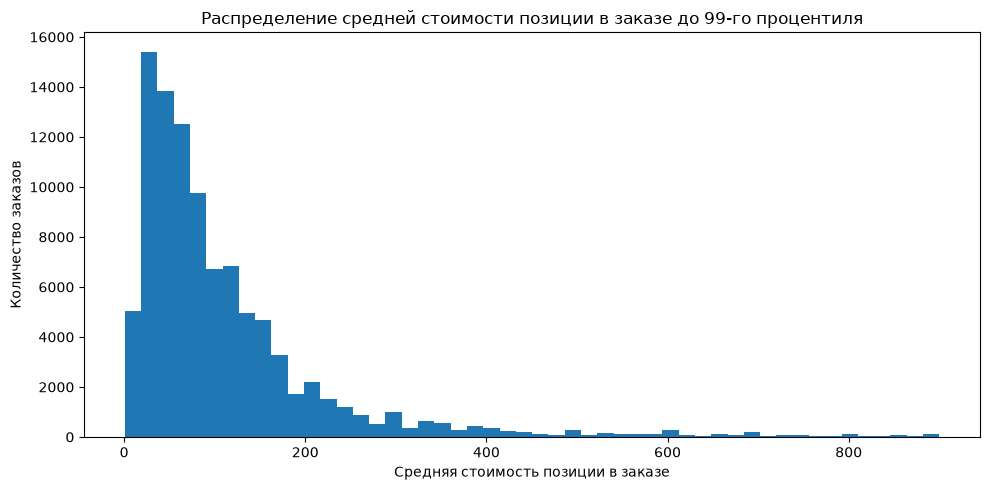

In [69]:
#увеличенный график основной части распределения
price_99 = orders_analytics["mean_item_price"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["mean_item_price"] <= price_99,
    "mean_item_price"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение средней стоимости позиции в заказе до 99-го процентиля")
plt.xlabel("Средняя стоимость позиции в заказе")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `mean_item_price` имеет выраженную правостороннюю асимметрию. Медианная средняя стоимость позиции в заказе составляет 79,0, тогда как среднее значение выше и составляет около 125,9. В 95% заказов средняя стоимость позиции не превышает 369, а в 99% — примерно 900. Максимальное значение достигает 6735, что указывает на наличие небольшого числа заказов с очень дорогими товарами и формирует длинный правый хвост распределения.

#### Исследование распределения max_item_price

In [70]:
orders_analytics["max_item_price"].describe()

count    98666.000000
mean       126.631705
std        191.688201
min          0.850000
25%         42.200000
50%         79.900000
75%        139.900000
max       6735.000000
Name: max_item_price, dtype: float64

In [71]:
#верхние процентили
orders_analytics["max_item_price"].quantile([0.90, 0.95, 0.99])

0.90    240.3500
0.95    369.9000
0.99    919.9315
Name: max_item_price, dtype: float64

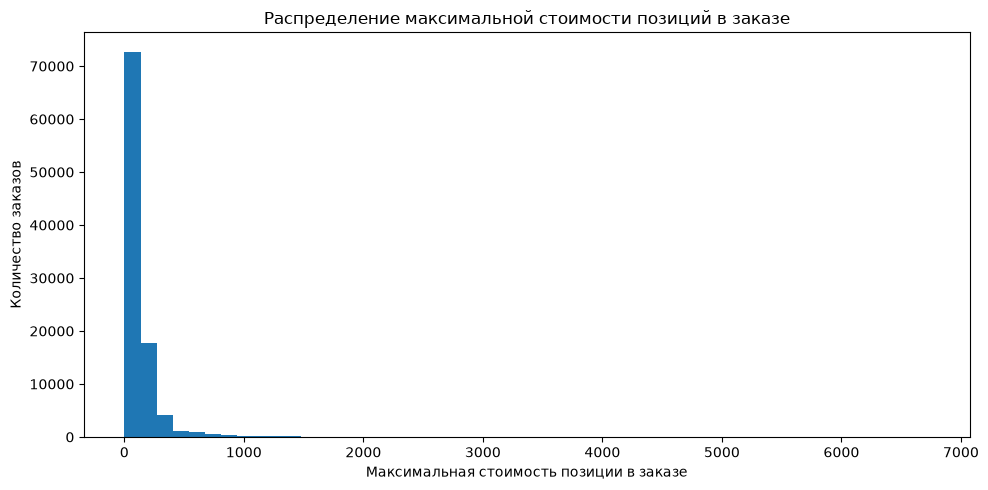

In [72]:
orders_analytics["max_item_price"].dropna().plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение максимальной стоимости позиций в заказе")
plt.xlabel("Максимальная стоимость позиции в заказе")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

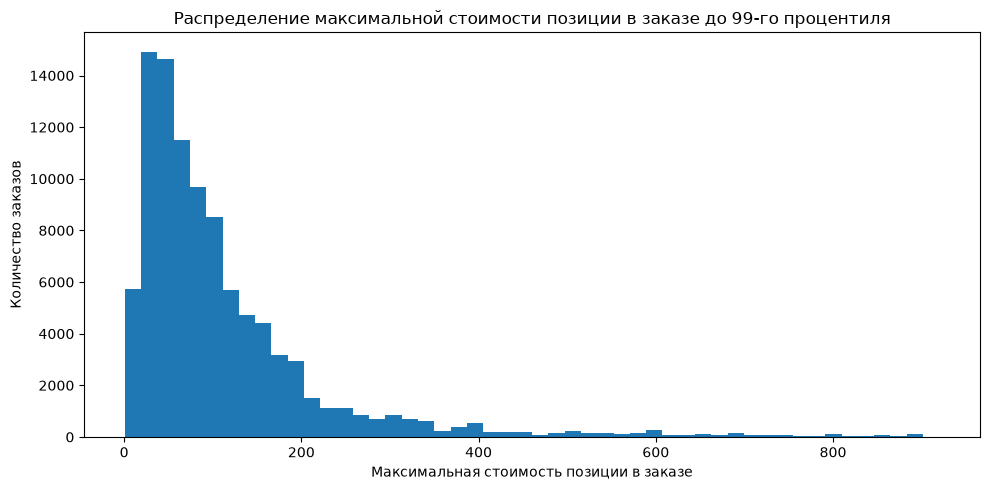

In [73]:
#увеличенный график основной части распределения
max_item_price_99 = orders_analytics["max_item_price"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["max_item_price"] <= max_item_price_99,
    "max_item_price"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение максимальной стоимости позиции в заказе до 99-го процентиля")
plt.xlabel("Максимальная стоимость позиции в заказе")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `max_item_price` имеет выраженную правостороннюю асимметрию. Медианная максимальная стоимость позиции в заказе составляет 79,9, тогда как среднее значение выше и составляет около 126,63. В 95% заказов максимальная стоимость позиции не превышает 369,9, а в 99% — примерно 919,9. Максимальное значение достигает 6735, что указывает на наличие небольшого числа заказов с очень дорогими товарами и формирует длинный правый хвост распределения.

Распределения `mean_item_price` и `max_item_price` очень похожи. Это логично с учётом предыдущего результата — около 90% заказов содержат всего одну позицию, а для заказа из одной позиции mean_item_price == max_item_price.

### 4.7.2. Общая стоимость заказа

In [74]:
orders_analytics["order_total"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: order_total, dtype: float64

In [75]:
#верхние процентили
orders_analytics["order_total"].quantile([0.90, 0.95, 0.99])

0.90     307.685
0.95     450.530
0.99    1063.321
Name: order_total, dtype: float64

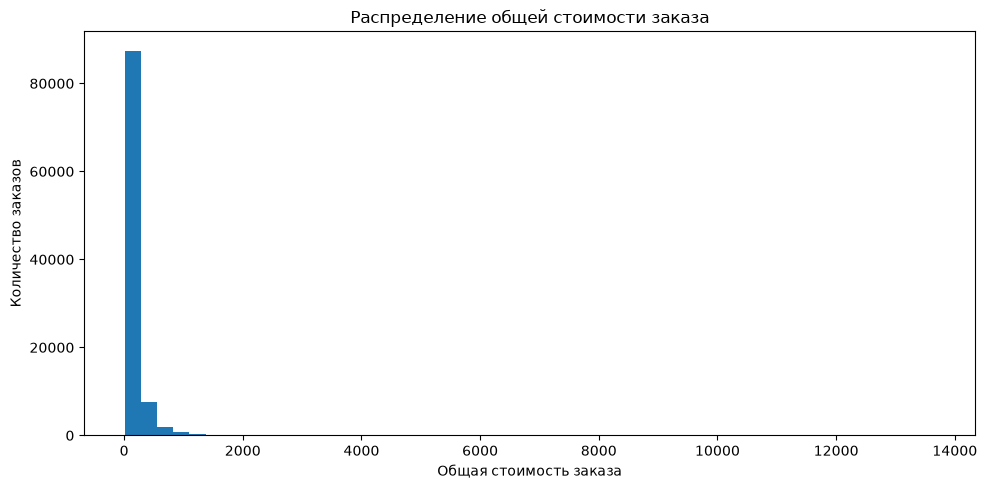

In [76]:
orders_analytics["order_total"].dropna().plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение общей стоимости заказа")
plt.xlabel("Общая стоимость заказа")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

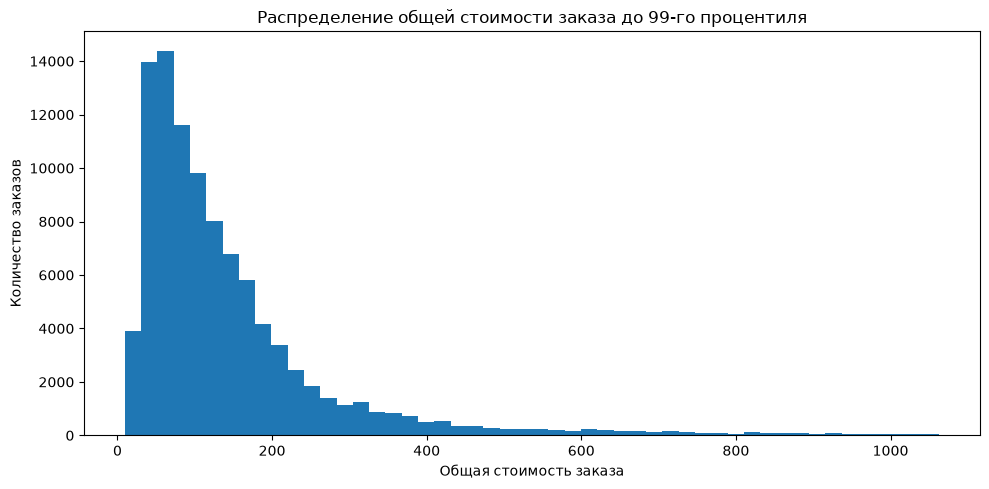

In [77]:
#увеличенный график основной части распределения
order_total_99 = orders_analytics["order_total"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["order_total"] <= order_total_99,
    "order_total"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение общей стоимости заказа до 99-го процентиля")
plt.xlabel("Общая стоимость заказа")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение общей стоимости заказа (`order_total`) имеет выраженную правостороннюю асимметрию. Медианная стоимость заказа составляет 105,29, тогда как среднее значение выше — около 160,58. В 95% заказов общая стоимость не превышает 450,53, а в 99% — около 1063,32. Максимальное значение достигает 13 664,08, что указывает на наличие небольшого числа очень дорогих заказов и формирует длинный правый хвост распределения.

### 4.7.3. Стоимость доставки

#### Исследование распределения total_freight

In [78]:
orders_analytics["total_freight"].describe()

count    98666.000000
mean        22.823562
std         21.650909
min          0.000000
25%         13.850000
50%         17.170000
75%         24.040000
max       1794.960000
Name: total_freight, dtype: float64

In [79]:
#верхние процентили
orders_analytics["total_freight"].quantile([0.90, 0.95, 0.99])

0.90     39.4950
0.95     54.9600
0.99    104.9835
Name: total_freight, dtype: float64

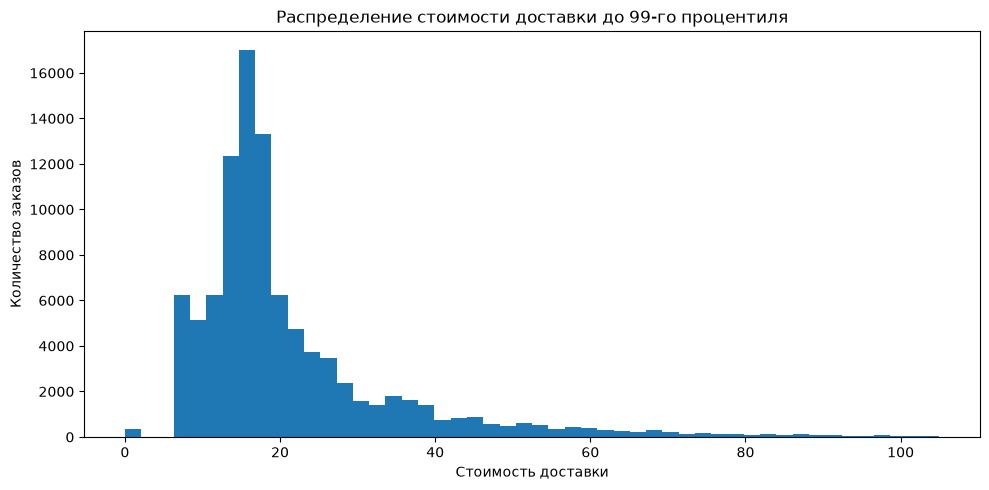

In [80]:
#увеличенный график основной части распределения
total_freight_99 = orders_analytics["total_freight"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["total_freight"] <= total_freight_99,
    "total_freight"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение стоимости доставки до 99-го процентиля")
plt.xlabel("Стоимость доставки")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `total_freight` имеет выраженную правостороннюю асимметрию. Медианная стоимость доставки в заказе составляет `17,17`, тогда как среднее значение — `22,82`, что связано с наличием небольшого числа дорогих доставок. 90% заказов имеют стоимость доставки не выше 39,49, 95% — не выше 54,96, а 99% — не выше 104,98. При этом максимальная стоимость доставки достигает 1794.96, поэтому в данных присутствует длинный правый хвост с редкими высокими значениями.

#### Исследование распределения mean_freight

In [81]:
orders_analytics["mean_freight"].describe()

count    98666.000000
mean        20.190469
std         15.797846
min          0.000000
25%         13.370000
50%         16.360000
75%         21.180000
max        409.680000
Name: mean_freight, dtype: float64

In [82]:
#верхние процентили
orders_analytics["mean_freight"].quantile([0.90, 0.95, 0.99])

0.90    34.150
0.95    45.420
0.99    85.069
Name: mean_freight, dtype: float64

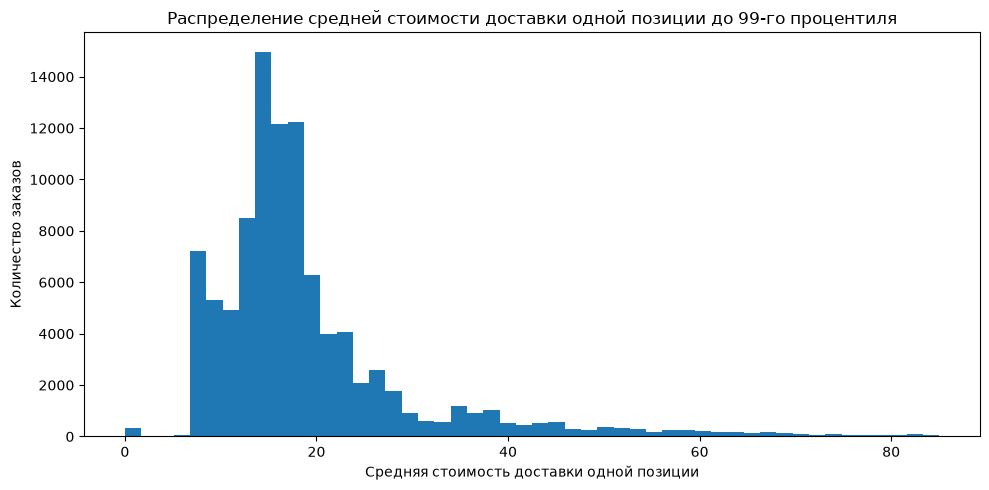

In [83]:
#увеличенный график основной части распределения
mean_freight_99 = orders_analytics["mean_freight"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["mean_freight"] <= mean_freight_99,
    "mean_freight"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение средней стоимости доставки одной позиции до 99-го процентиля")
plt.xlabel("Средняя стоимость доставки одной позиции")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `mean_freight` имеет выраженную правостороннюю асимметрию. Медианная средняя стоимость доставки составляет 16,36, тогда как среднее значение выше и составляет около 20,19. В 95% заказов средняя стоимость доставки не превышает 45.42, а в 99% — примерно 85.069. Максимальное значение достигает 409.68, что указывает на наличие небольшого числа заказов с очень дорогими доставками и формирует длинный правый хвост распределения.

#### Исследование распределения freight_ratio

In [84]:
orders_analytics["freight_ratio"].describe()

count    98666.000000
mean         0.208804
std          0.125749
min          0.000000
25%          0.116502
50%          0.183256
75%          0.275463
max          0.955451
Name: freight_ratio, dtype: float64

In [85]:
#верхние процентили
orders_analytics["freight_ratio"].quantile([0.90, 0.95, 0.99])

0.90    0.383668
0.95    0.456331
0.99    0.593811
Name: freight_ratio, dtype: float64

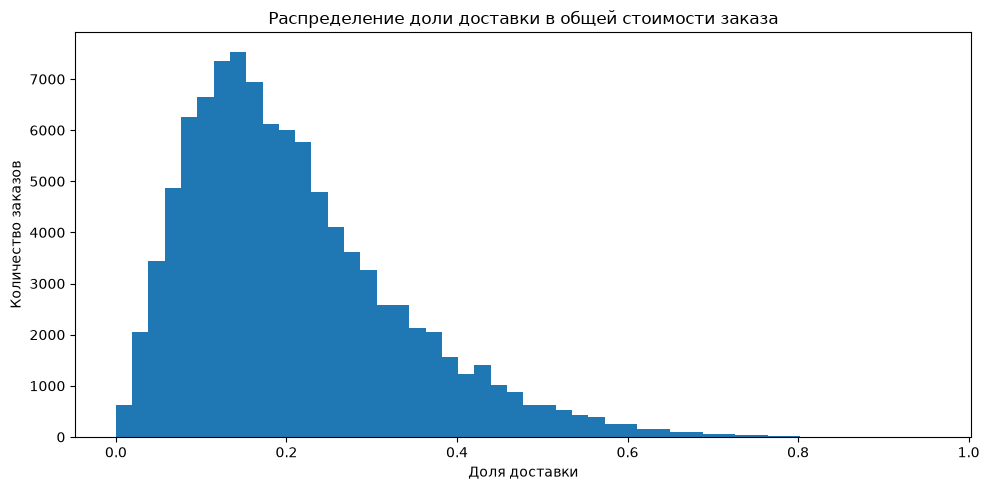

In [86]:
orders_analytics["freight_ratio"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение доли доставки в общей стоимости заказа")
plt.xlabel("Доля доставки")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

In [87]:
#доля заказов с бесплатной доставкой
(orders_analytics["freight_ratio"].dropna().eq(0).mean()) * 100

np.float64(0.342569882228934)

In [88]:
orders_analytics["total_freight"].dropna().eq(0).mean() * 100

np.float64(0.342569882228934)

Доля доставки в общей стоимости заказа имеет правосторонне асимметричное распределение. Медианное значение составляет около 18,3%, а среднее — 20,9%. В 90% заказов доставка составляет не более 38,4% общей стоимости, а в 99% — не более 59,4%. При этом встречаются редкие заказы, в которых стоимость доставки достигает почти всей стоимости заказа, что формирует правый хвост распределения. Бесплатная доставка встречается редко — примерно в 0,34% заказов.

### 4.7.4. Физические характеристики заказа

#### Исследование распределения total_weight_g

In [89]:
orders_analytics["total_weight_g"].describe()

count     98650.000000
mean       2390.415307
std        4773.529840
min           0.000000
25%         300.000000
50%         750.000000
75%        2068.750000
max      184400.000000
Name: total_weight_g, dtype: float64

In [90]:
#верхние процентили
orders_analytics["total_weight_g"].quantile([0.90, 0.95, 0.99])

0.90     6550.0
0.95    10600.0
0.99    22350.0
Name: total_weight_g, dtype: float64

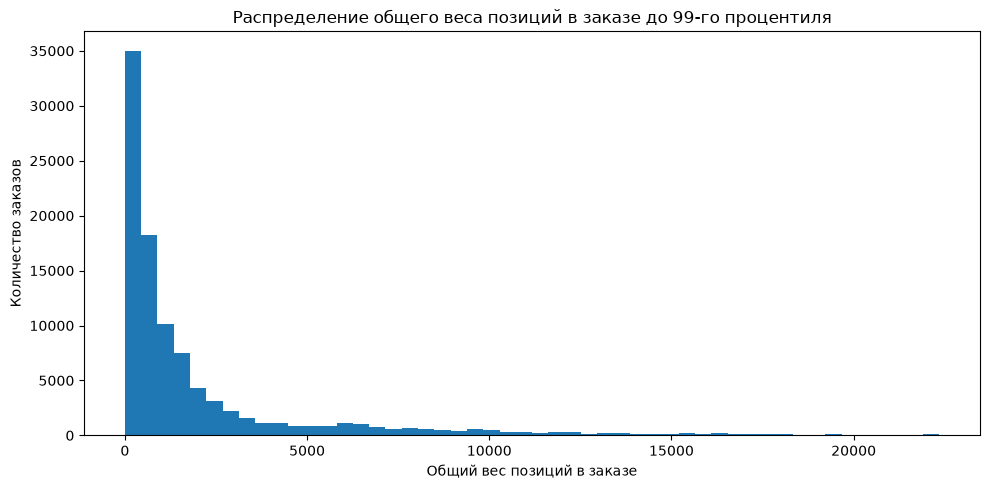

In [91]:
#увеличенный график основной части распределения
total_weight_g_99 = orders_analytics["total_weight_g"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["total_weight_g"] <= total_weight_g_99,
    "total_weight_g"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение общего веса позиций в заказе до 99-го процентиля")
plt.xlabel("Общий вес позиций в заказе")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `total_weight_g` имеет выраженную правостороннюю асимметрию. Медианный общий вес позиций в заказе составляет 750, тогда как среднее значение значительно выше и составляет около 2390,4. В 95% заказов общий вес позиций в заказе не превышает 10600, а в 99% — 22350. Максимальное значение достигает 184400, что указывает на наличие небольшого числа заказов с очень большим общим весом позиций в заказе и формирует длинный правый хвост распределения.

#### Исследование распределения total_volume_cm3

In [92]:
orders_analytics["total_volume_cm3"].describe()

count    9.865000e+04
mean     1.740425e+04
std      3.040383e+04
min      1.680000e+02
25%      2.964000e+03
50%      7.260000e+03
75%      1.987200e+04
max      1.476000e+06
Name: total_volume_cm3, dtype: float64

In [93]:
#верхние процентили
orders_analytics["total_volume_cm3"].quantile([0.90, 0.95, 0.99])

0.90     43200.0
0.95     64000.0
0.99    136500.0
Name: total_volume_cm3, dtype: float64

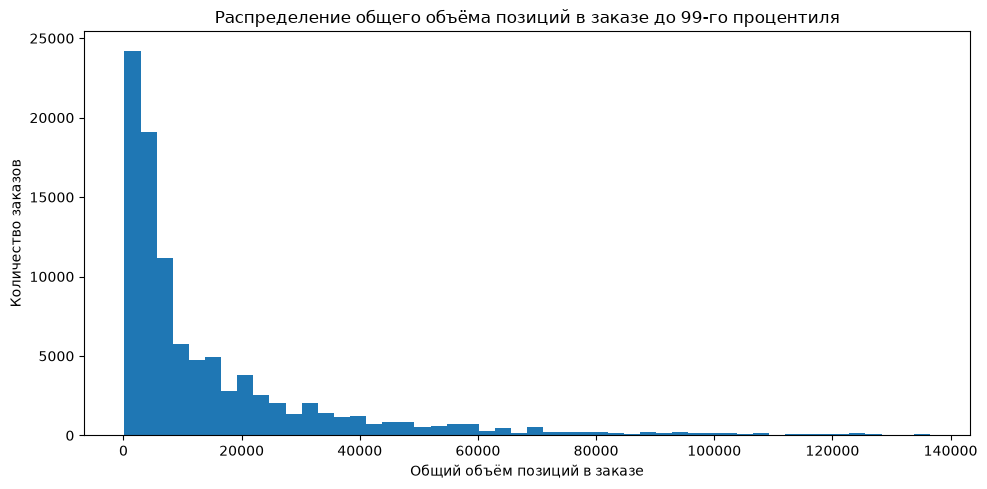

In [94]:
#увеличенный график основной части распределения
total_volume_cm3_99 = orders_analytics["total_volume_cm3"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["total_volume_cm3"] <= total_volume_cm3_99,
    "total_volume_cm3"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение общего объёма позиций в заказе до 99-го процентиля")
plt.xlabel("Общий объём позиций в заказе")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `total_volume_cm3` имеет выраженную правостороннюю асимметрию. Медианный общий объём позиций в заказе составляет 7 260 см³, тогда как среднее значение значительно выше — около 17 404 см³. В 95% заказов общий объём не превышает 64 000 см³, а в 99% — 136 500 см³. Максимальное значение достигает 1 476 000 см³, что указывает на наличие небольшого числа заказов с очень большим объёмом и формирует длинный правый хвост распределения.

## 4.8 Платёжные характеристики

### 4.8.1. Способ оплаты

In [95]:
main_payment_type_distribution = orders_analytics.groupby("main_payment_type").agg(num_of_orders = ("order_id", "size"))

main_payment_type_distribution["share_pct"] = (
    main_payment_type_distribution["num_of_orders"]
    / orders_analytics["main_payment_type"].notna().sum()
    * 100
)

main_payment_type_distribution["share_pct"] = (
    main_payment_type_distribution["share_pct"].round(3)
)

main_payment_type_distribution = (
    main_payment_type_distribution
    .sort_values(by="num_of_orders", ascending=False)
)
main_payment_type_distribution

,num_of_orders,share_pct
main_payment_type,,
credit_card,74935,75.357
boleto,19784,19.895
voucher,3191,3.209
debit_card,1527,1.536
not_defined,3,0.003


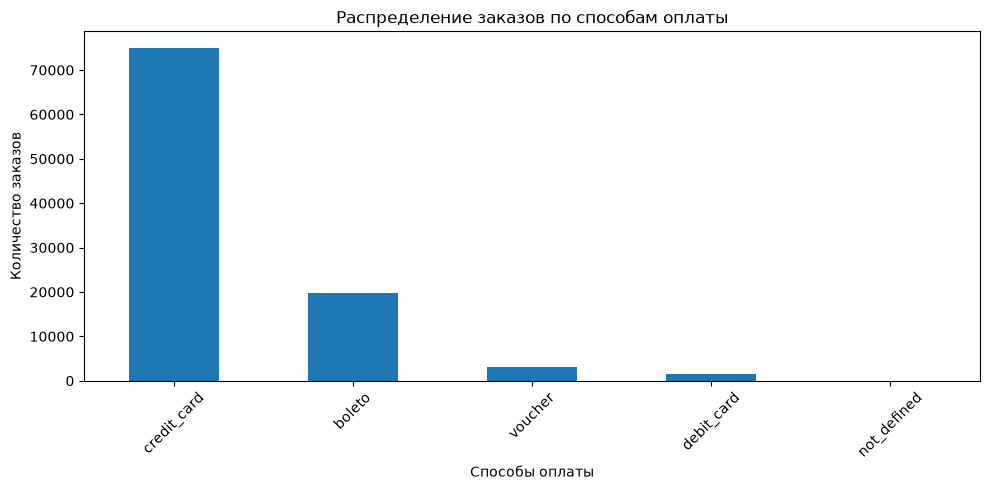

In [96]:
main_payment_type_distribution["num_of_orders"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по способам оплаты")
plt.xlabel("Способы оплаты")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Основным способом оплаты является credit_card, на который приходится около 75% заказов. Вторым по распространённости является boleto — около 20%. voucher и debit_card используются значительно реже — примерно в 3,2% и 1,5% заказов соответственно. Таким образом, структура способов оплаты сильно смещена в сторону оплаты кредитной картой.

### 4.8.2. Рассрочка

In [97]:
installments_distribution = (
    orders_analytics["max_installments"]
    .value_counts()
    .sort_index()
)

installments_distribution

max_installments
0.0         2
1.0     48268
2.0     12363
3.0     10429
4.0      7070
5.0      5227
6.0      3908
7.0      1622
8.0      4251
9.0       644
10.0     5315
11.0       23
12.0      133
13.0       16
14.0       15
15.0       74
16.0        5
17.0        8
18.0       27
20.0       17
21.0        3
22.0        1
23.0        1
24.0       18
Name: count, dtype: int64

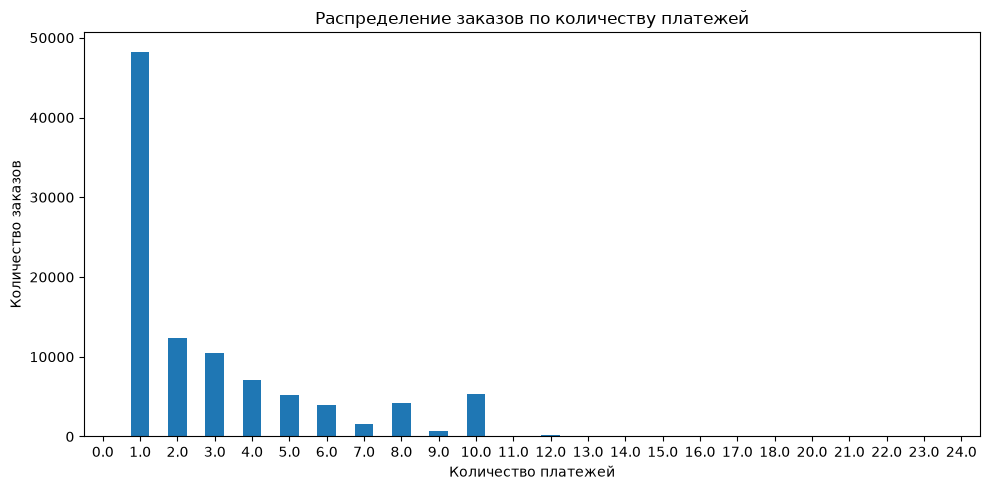

In [98]:
installments_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по количеству платежей")
plt.xlabel("Количество платежей")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [99]:
orders_analytics["used_installments"].dropna().value_counts()

used_installments
1.0    51170
0.0    48270
Name: count, dtype: int64

In [100]:
orders_analytics["used_installments"].dropna().value_counts(normalize=True) * 100

used_installments
1.0    51.458166
0.0    48.541834
Name: proportion, dtype: float64

In [101]:
valid_installments = orders_analytics[
    ["max_installments", "used_installments"]
].dropna()

(
    valid_installments["used_installments"]
    != valid_installments["max_installments"].gt(1)
).sum()

np.int64(0)

Оплата несколькими платежами достаточно распространена: рассрочка используется примерно в 51,46% заказов, тогда как 48,54% оплачиваются без рассрочки. Наиболее частым отдельным значением является один платёж, однако среди заказов с рассрочкой преобладают небольшие количества платежей. Варианты с большим числом платежей встречаются значительно реже.

### 4.8.3. Несколько способов оплаты

In [102]:
orders_analytics["payment_types_count"].value_counts()

payment_types_count
1.0    97194
2.0     2246
Name: count, dtype: int64

In [103]:
orders_analytics["has_multiple_payment_types"].dropna().value_counts(normalize=True) * 100

has_multiple_payment_types
0.0    97.741352
1.0     2.258648
Name: proportion, dtype: float64

In [104]:
payments_count_distribution = orders_analytics["payments_count"].value_counts().sort_index()
payments_count_distribution

payments_count
1.0     96479
2.0      2382
3.0       301
4.0       108
5.0        52
6.0        36
7.0        28
8.0        11
9.0         9
10.0        5
11.0        8
12.0        8
13.0        3
14.0        2
15.0        2
19.0        2
21.0        1
22.0        1
26.0        1
29.0        1
Name: count, dtype: int64

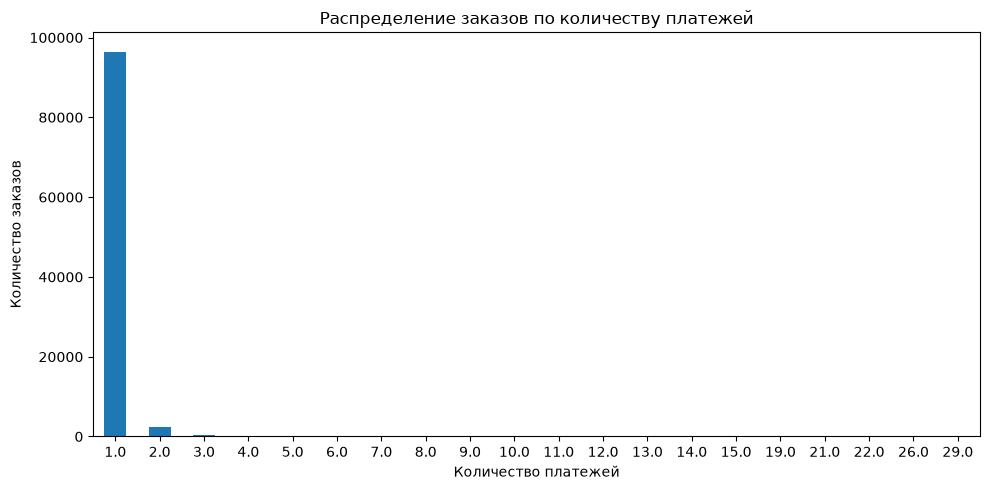

In [105]:
payments_count_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Распределение заказов по количеству платежей")
plt.xlabel("Количество платежей")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [106]:
orders_analytics["payments_count"].dropna().gt(1).mean() * 100

np.float64(2.977674979887369)

In [107]:
valid_payments = orders_analytics[
    ["payment_types_count", "has_multiple_payment_types"]
].dropna()

(
    valid_payments["has_multiple_payment_types"]
    != valid_payments["payment_types_count"].gt(1)
).sum()

np.int64(0)

In [108]:
valid_payments_count = orders_analytics[
    ["payment_types_count", "payments_count"]
].dropna()

(
    valid_payments_count["payment_types_count"]
    > valid_payments_count["payments_count"]
).sum()

np.int64(0)

Подавляющее большинство заказов оплачивается одним способом: около 97,7% заказов имеют только один тип оплаты, а несколько способов используются примерно в 2,3% случаев. Большинство заказов также содержит только одну платёжную запись, а случаи с несколькими платежами встречаются значительно реже - 2,97%. Таким образом, комбинированная оплата для данного набора данных нехарактерна.

## 4.9 Процесс доставки

### 4.9.1. Время подтверждения заказа

In [109]:
orders_analytics["approval_time_days"].describe()

count    99281.000000
mean         0.434129
std          1.084917
min          0.000000
25%          0.008958
50%          0.014306
75%          0.607535
max        187.882523
Name: approval_time_days, dtype: float64

In [110]:
#верхние процентили
orders_analytics["approval_time_days"].quantile([0.90, 0.95, 0.99])

0.90    1.444155
0.95    2.019317
0.99    3.756937
Name: approval_time_days, dtype: float64

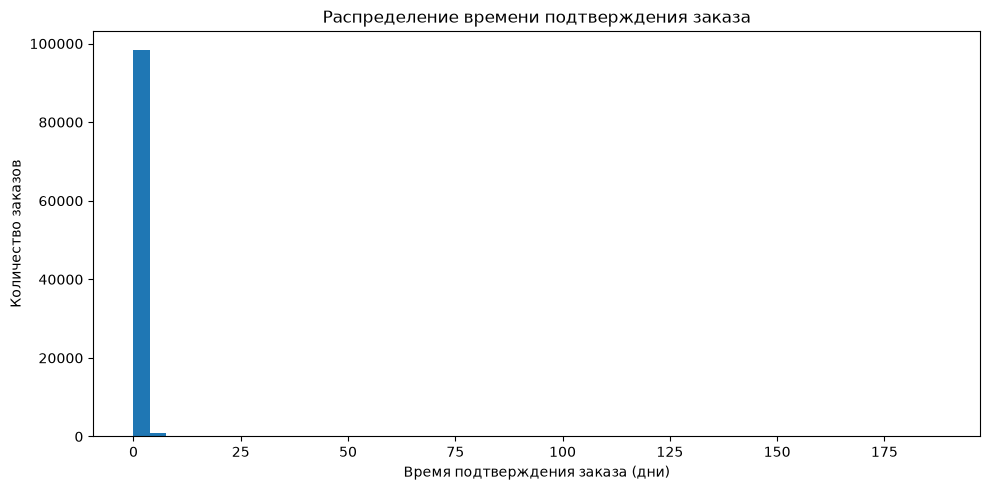

In [111]:
orders_analytics["approval_time_days"].dropna().plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение времени подтверждения заказа")
plt.xlabel("Время подтверждения заказа (дни)")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

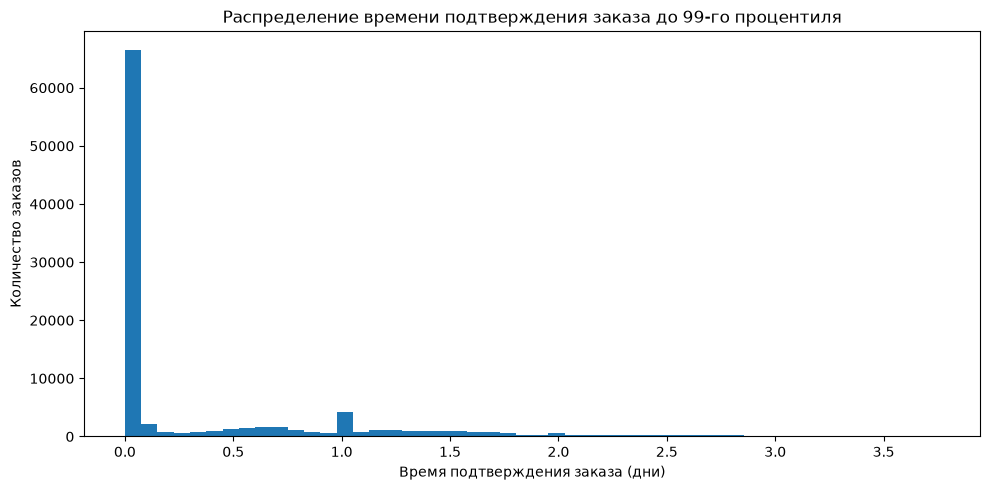

In [112]:
#увеличенный график основной части распределения
approval_time_days_99 = orders_analytics["approval_time_days"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["approval_time_days"] <= approval_time_days_99,
    "approval_time_days"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение времени подтверждения заказа до 99-го процентиля")
plt.xlabel("Время подтверждения заказа (дни)")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `approval_time_days` имеет выраженную правостороннюю асимметрию. Большинство заказов подтверждается достаточно быстро: медианное время составляет около 21 минуты, а 75% заказов подтверждаются менее чем за 15 часов. В 95% случаев подтверждение занимает не более 2 дней, а в 99% — не более 3,76 дня. При этом встречаются редкие аномально долгие подтверждения, вплоть до 187,9 дня, которые формируют длинный правый хвост и заметно увеличивают среднее значение.

### 4.9.2. Передача перевозчику

In [113]:
orders_analytics["carrier_handoff_time_days"].describe()

count    96285.000000
mean         2.859186
std          3.498574
min          0.000174
25%          0.901539
50%          1.851667
75%          3.624051
max        125.762569
Name: carrier_handoff_time_days, dtype: float64

In [114]:
#верхние процентили
orders_analytics["carrier_handoff_time_days"].quantile([0.90, 0.95, 0.99])

0.90     6.029831
0.95     8.160887
0.99    17.206891
Name: carrier_handoff_time_days, dtype: float64

In [115]:
orders_analytics["invalid_approval_carrier_order"].dropna().mean() * 100

np.float64(1.366639514888225)

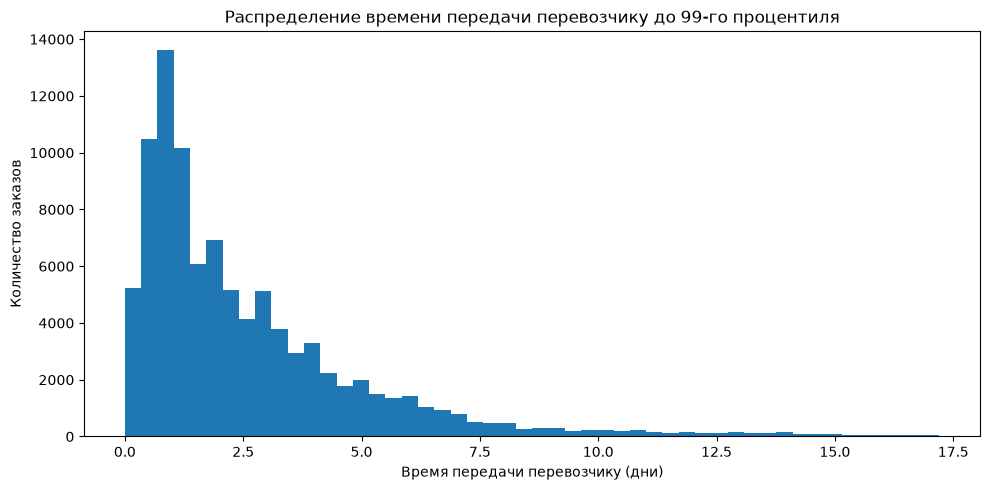

In [116]:
#увеличенный график основной части распределения
carrier_handoff_time_days_99 = orders_analytics["carrier_handoff_time_days"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["carrier_handoff_time_days"] <= carrier_handoff_time_days_99,
    "carrier_handoff_time_days"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение времени передачи перевозчику до 99-го процентиля")
plt.xlabel("Время передачи перевозчику (дни)")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `carrier_handoff_time_days` имеет выраженную правостороннюю асимметрию. Медианное время от подтверждения заказа до передачи перевозчику составляет около 1,85 дня, тогда как среднее — 2,86 дня. В 95% случаев передача происходит не более чем за 8,16 дня, а в 99% — за 17,21 дня. При этом встречаются редкие значения вплоть до 125,76 дня, формирующие длинный правый хвост. Кроме того, примерно для 1,37% заказов отмечена некорректная последовательность между подтверждением заказа и передачей перевозчику.

### 4.9.3. Фактическое время доставки

In [117]:
orders_analytics["delivery_time_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64

In [118]:
#верхние процентили
orders_analytics["delivery_time_days"].quantile([0.90, 0.95, 0.99])

0.90    23.097604
0.95    29.276016
0.99    46.049913
Name: delivery_time_days, dtype: float64

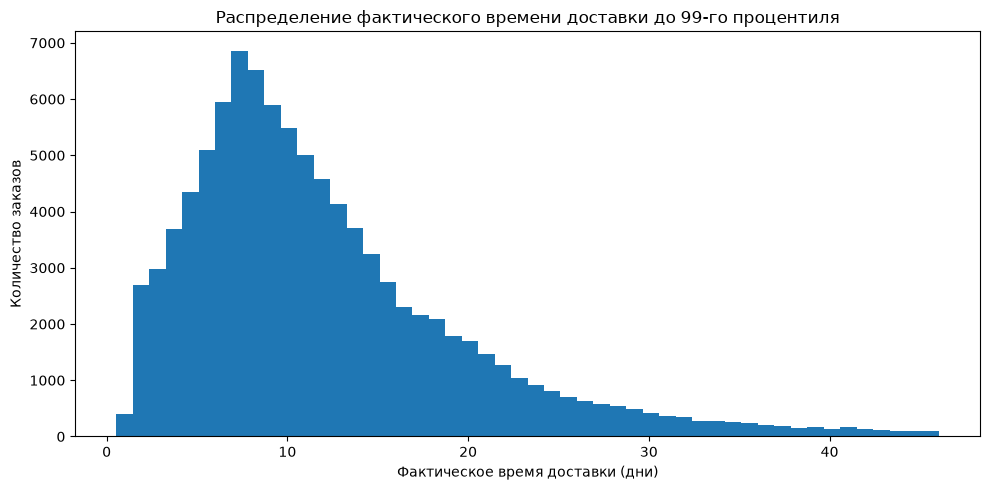

In [119]:
#увеличенный график основной части распределения
delivery_time_days_99 = orders_analytics["delivery_time_days"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["delivery_time_days"] <= delivery_time_days_99,
    "delivery_time_days"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение фактического времени доставки до 99-го процентиля")
plt.xlabel("Фактическое время доставки (дни)")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `delivery_time_days` имеет выраженную правостороннюю асимметрию. Медианное фактическое время доставки составляет около 10,22 дня, а среднее — 12,56 дня. В 75% случаев доставка занимает не более 15,72 дня, в 95% — не более 29,28 дня, а в 99% — не более 46,05 дня. При этом встречаются редкие очень длительные доставки вплоть до 209,63 дня, которые формируют длинный правый хвост распределения.

### 4.9.4. Ожидаемый срок доставки

In [120]:
orders_analytics["estimated_delivery_time_days"].describe()

count    99441.000000
mean        23.767650
std          8.832371
min          1.648993
25%         18.331690
50%         23.240370
75%         28.424861
max        155.135463
Name: estimated_delivery_time_days, dtype: float64

In [121]:
#верхние процентили
orders_analytics["estimated_delivery_time_days"].quantile([0.90, 0.95, 0.99])

0.90    34.322049
0.95    38.484340
0.99    50.422097
Name: estimated_delivery_time_days, dtype: float64

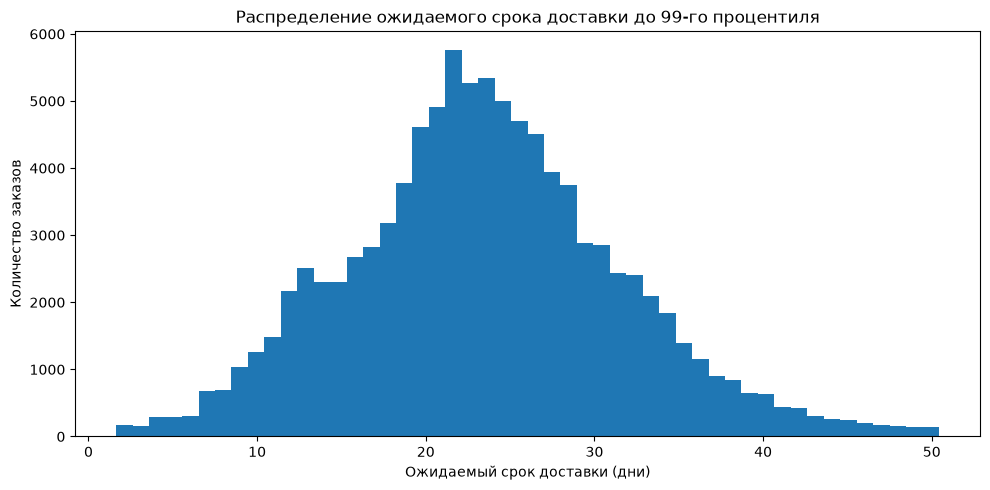

In [122]:
#увеличенный график основной части распределения
estimated_delivery_time_days_99 = orders_analytics["estimated_delivery_time_days"].quantile(0.99)

orders_analytics.loc[
    orders_analytics["estimated_delivery_time_days"] <= estimated_delivery_time_days_99,
    "estimated_delivery_time_days"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение ожидаемого срока доставки до 99-го процентиля")
plt.xlabel("Ожидаемый срок доставки (дни)")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Распределение `estimated_delivery_time_days` сосредоточено преимущественно около 20–30 дней и значительно менее асимметрично, чем распределение фактического времени доставки. Медианный ожидаемый срок составляет 23,24 дня, а средний — 23,77 дня. Для 95% заказов ожидаемый срок не превышает 38,48 дня, а для 99% — 50,42 дня. При этом встречаются редкие высокие значения вплоть до 155,14 дня, формирующие правый хвост распределения.

## 4.10 Соблюдение ожидаемых сроков

### 4.10.1. Доля опоздавших заказов

In [123]:
orders_analytics["is_late_delivery"].value_counts()

is_late_delivery
False    88649
True      7827
Name: count, dtype: int64

In [124]:
orders_analytics["is_late_delivery"].value_counts(normalize=True) * 100

is_late_delivery
False    91.887101
True      8.112899
Name: proportion, dtype: float64

Среди заказов с фактической доставкой 91,89% были доставлены не позднее ожидаемого срока, а 8,11% заказов были доставлены с опозданием. Таким образом, большинство доставок укладывается в заявленные сроки, однако примерно каждый двенадцатый доставленный заказ оказывается просроченным.

### 4.10.2. Насколько сильно опаздывают

In [125]:
late_orders = orders_analytics[orders_analytics["is_late_delivery"] == True]
late_orders["delay_days"].describe()

count    7827.000000
mean        9.552206
std        13.951700
min         0.002500
25%         1.867193
50%         5.807894
75%        11.822471
max       188.975081
Name: delay_days, dtype: float64

In [126]:
#верхние процентили
late_orders["delay_days"].quantile([0.90, 0.95, 0.99])

0.90    21.531486
0.95    29.639211
0.99    62.759613
Name: delay_days, dtype: float64

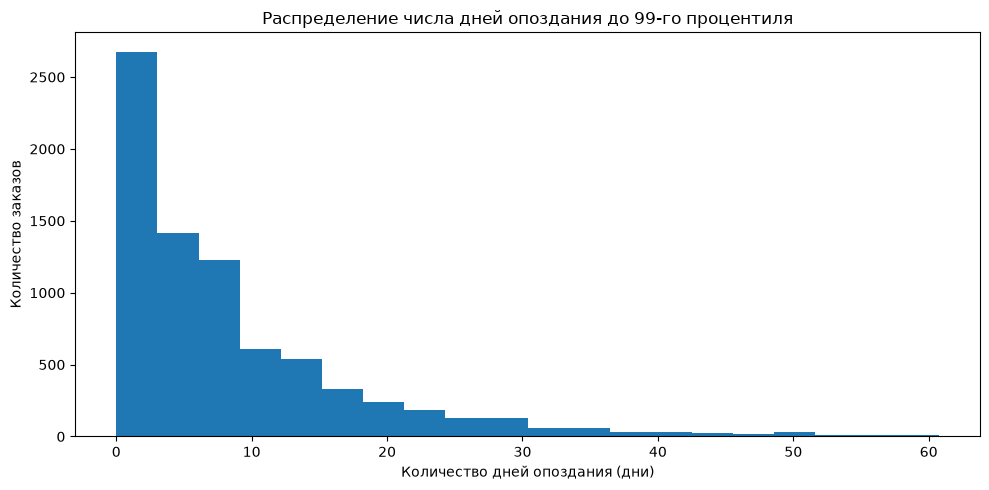

In [127]:
#увеличенный график основной части распределения
delay_days_99 = late_orders["delay_days"].quantile(0.99)

late_orders.loc[
    late_orders["delay_days"] <= delay_days_99,
    "delay_days"
].plot(
    kind="hist",
    bins=20,
    figsize=(10, 5)
)

plt.title("Распределение числа дней опоздания до 99-го процентиля")
plt.xlabel("Количество дней опоздания (дни)")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Среди просроченных заказов медианное опоздание составляет около 5,8 дня, а среднее — около 9,6 дня. 90% опоздавших заказов задерживаются не более чем на 21,5 дня, а 99% — не более чем на 62,8 дня. Распределение имеет выраженную правостороннюю асимметрию и длинный правый хвост из редких заказов с очень большими задержками.

### 4.10.3. Насколько раньше привозят остальные

In [128]:
early_orders = orders_analytics[
    orders_analytics["early_delivery_days"] > 0
]

In [129]:
early_orders["early_delivery_days"].describe()

count    88649.000000
mean        13.009531
std          7.378087
min          0.000058
25%          7.997037
50%         12.317963
75%         17.037813
max        146.016123
Name: early_delivery_days, dtype: float64

In [130]:
early_orders["early_delivery_days"].quantile([0.90, 0.95, 0.99])

0.90    21.955412
0.95    26.260512
0.99    35.374813
Name: early_delivery_days, dtype: float64

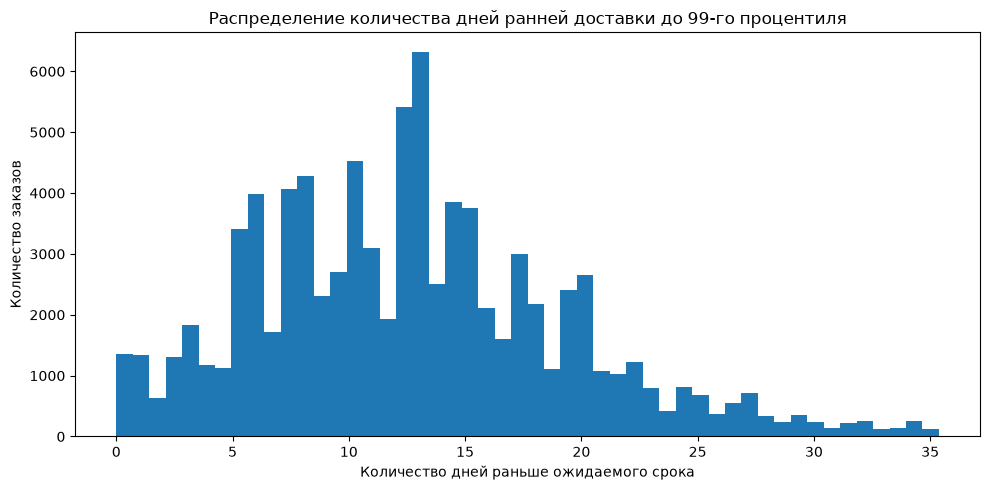

In [131]:
early_delivery_days_99 = early_orders["early_delivery_days"].quantile(0.99)

early_orders.loc[
    early_orders["early_delivery_days"] <= early_delivery_days_99,
    "early_delivery_days"
].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Распределение количества дней ранней доставки до 99-го процентиля")
plt.xlabel("Количество дней раньше ожидаемого срока")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Среди заказов, доставленных раньше ожидаемого срока, медианное опережение составляет около 12,3 дня, а среднее — около 13 дней. В 90% случаев заказ доставляется не более чем на 22 дня раньше срока, в 95% — не более чем на 26,3 дня, а в 99% — не более чем на 35,4 дня. Распределение имеет правый хвост: встречаются редкие случаи очень ранней доставки, вплоть до 146 дней до ожидаемой даты.

## 4.11. Географический EDA

### 4.11.1. Количество заказов по штатам

In [132]:
orders_by_state = (
    orders_analytics.groupby("customer_state")
    .agg(num_of_orders=("order_id", "size"))
)

orders_by_state["share_pct"] = (
    orders_by_state["num_of_orders"]
    / orders_analytics["customer_state"].notna().sum()
    * 100
)

orders_by_state["share_pct"] = (
    orders_by_state["share_pct"].round(2)
)

orders_by_state = orders_by_state.sort_values(by="num_of_orders", ascending=False)

orders_by_state

,num_of_orders,share_pct
customer_state,,
SP,41746,41.98
RJ,12852,12.92
MG,11635,11.70
RS,5466,5.50
PR,5045,5.07
SC,3637,3.66
BA,3380,3.40
DF,2140,2.15
ES,2033,2.04


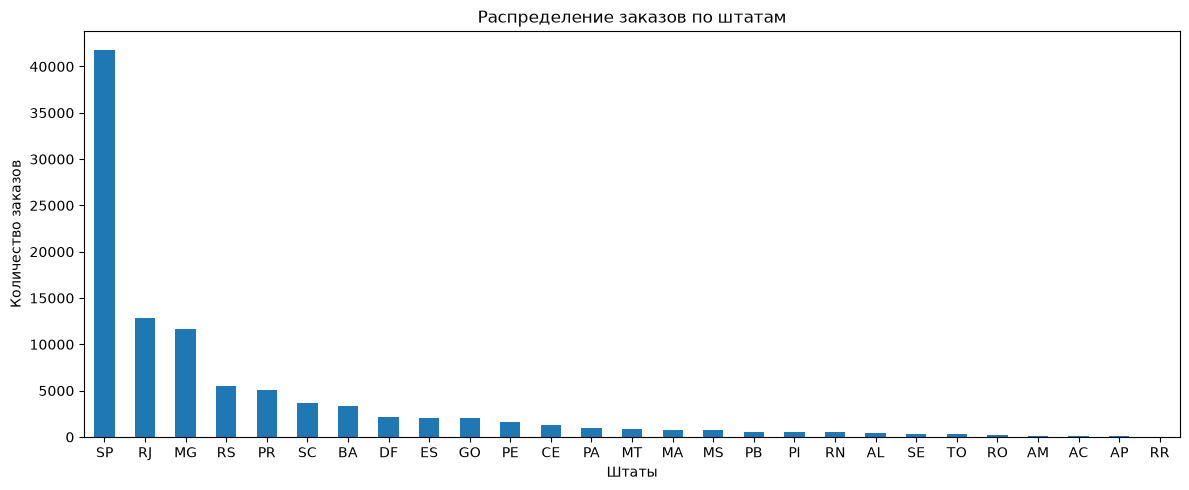

In [133]:
orders_by_state["num_of_orders"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Распределение заказов по штатам")
plt.xlabel("Штаты")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Распределение заказов по штатам сильно неравномерно. Наибольшее количество заказов приходится на штат `SP` — 41 746 заказов (41,98%). Далее следуют RJ — 12,92% и MG — 11,70%. В совокупности три крупнейших штата формируют около 66,6% всех заказов, тогда как на большинство остальных штатов приходится значительно меньшая доля. Таким образом, клиентская база имеет выраженную географическую концентрацию.

### 4.11.2. Доставка по штатам

In [134]:
delivery_by_state = (
    orders_analytics.groupby("customer_state")
    .agg(num_orders=("order_id", "size"),
         median_delivery_tyme_days=("delivery_time_days", "median"),
         share_late_delivery=("is_late_delivery", "mean"),
         median_delivery_delta_days=("delivery_delay_days", "median"))
)
delivery_by_state

,num_orders,median_delivery_tyme_days,share_late_delivery,median_delivery_delta_days
customer_state,,,,
AC,81,18.356528,0.0375,-21.197367
AL,413,22.332917,0.239295,-9.434537
AM,148,25.875139,0.041379,-18.188414
AP,68,24.347025,0.044776,-21.161123
BA,3380,16.913964,0.140356,-11.563426
CE,1336,18.209201,0.153245,-12.273970
DF,2140,11.364925,0.070673,-12.064184
ES,2033,13.636956,0.122306,-11.153183
GO,2020,13.949606,0.081758,-12.305347


In [135]:
delivery_by_state["share_late_delivery"] *= 100

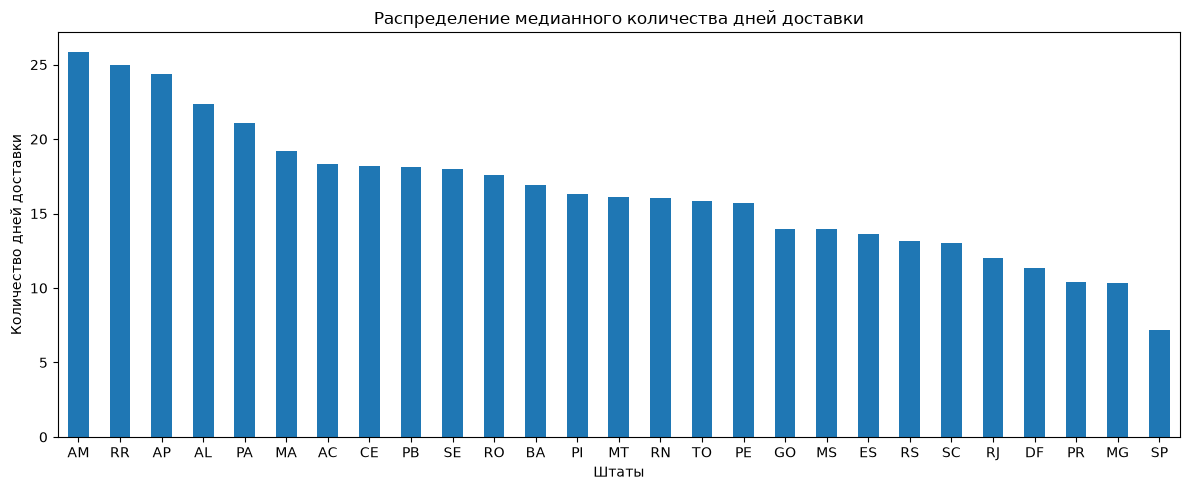

In [136]:
delivery_by_state.sort_values(by="median_delivery_tyme_days", ascending=False)["median_delivery_tyme_days"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Распределение медианного количества дней доставки")
plt.xlabel("Штаты")
plt.ylabel("Количество дней доставки")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

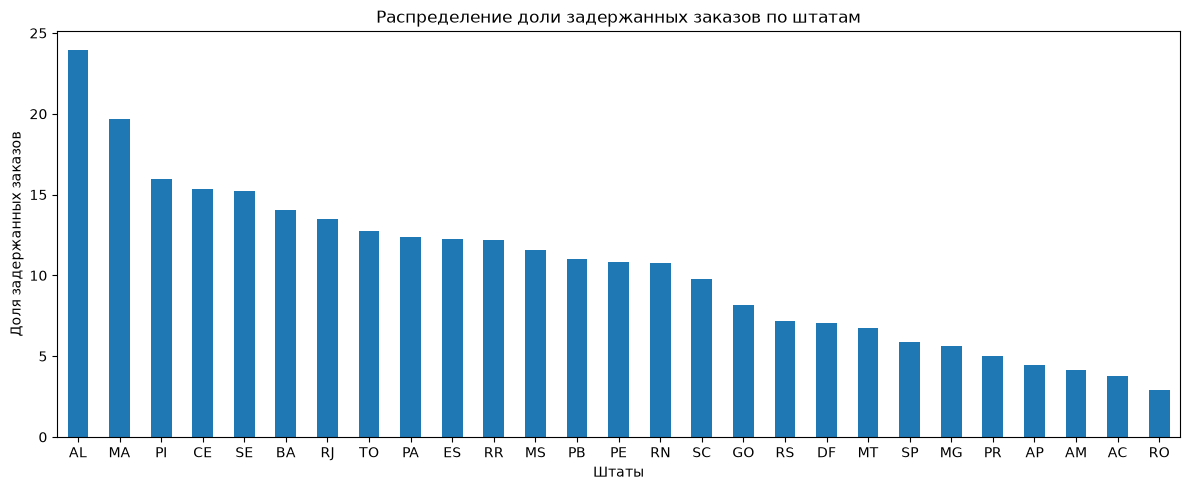

In [137]:
delivery_by_state.sort_values(by="share_late_delivery", ascending=False)["share_late_delivery"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Распределение доли задержанных заказов по штатам")
plt.xlabel("Штаты")
plt.ylabel("Доля задержанных заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

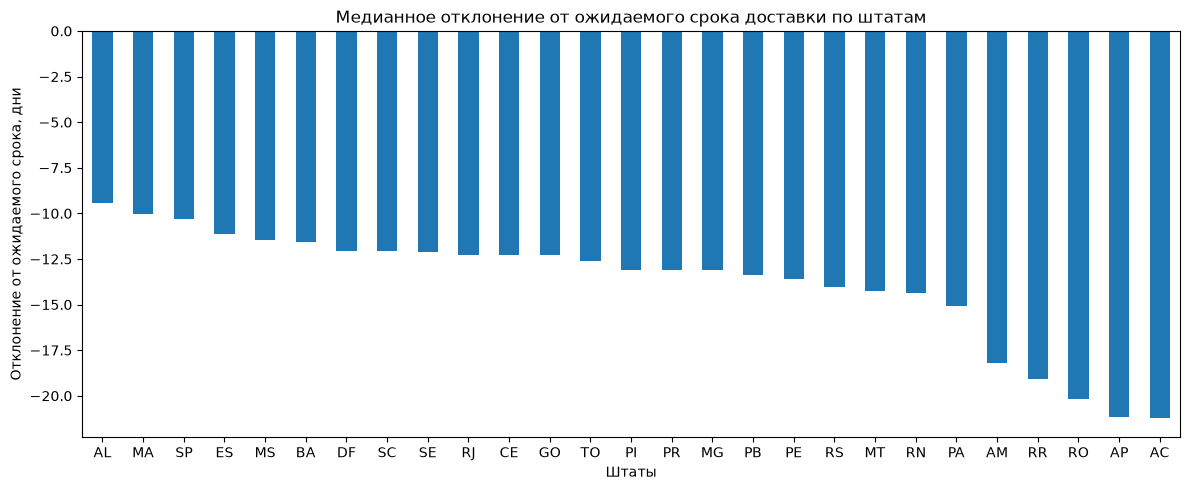

In [138]:
delivery_by_state.sort_values(by="median_delivery_delta_days", ascending=False)["median_delivery_delta_days"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Медианное отклонение от ожидаемого срока доставки по штатам")
plt.xlabel("Штаты")
plt.ylabel("Отклонение от ожидаемого срока, дни")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Характеристики доставки заметно различаются между штатами. Медианное время доставки варьируется примерно от 7 до 26 дней, а доля заказов, доставленных позже ожидаемого срока, также существенно зависит от региона. При этом медианное отклонение фактической доставки от ожидаемого срока отрицательно во всех штатах, что означает, что типичный заказ доставляется раньше обещанной даты. Величина этого запаса различается между регионами, что указывает на географические особенности сроков и качества доставки.

### 4.11.3. Плохие отзывы по штатам

In [139]:
# Оставляем только заказы, для которых есть информация об отзыве
reviewed_orders = orders_analytics.dropna(
    subset=["customer_state", "bad_review"]
)

reviews_by_state = (
    reviewed_orders
    .groupby("customer_state")
    .agg(
        reviewed_orders_count=("bad_review", "size"),  # число заказов с отзывом
        bad_reviews_count=("bad_review", "sum"),       # число плохих отзывов
        bad_review_rate=("bad_review", "mean")         # доля плохих отзывов
    )
)

# Переводим долю в проценты
reviews_by_state["bad_review_rate"] *= 100

# Для удобства сортируем по доле плохих отзывов
reviews_by_state = reviews_by_state.sort_values(
    by="bad_review_rate",
    ascending=False
)

reviews_by_state

,reviewed_orders_count,bad_reviews_count,bad_review_rate
customer_state,,,
RR,46,11.0,23.913043
AL,410,98.0,23.902439
MA,742,162.0,21.832884
SE,349,76.0,21.776504
RJ,12687,2625.0,20.690471
CE,1326,261.0,19.683258
PA,962,188.0,19.542620
BA,3340,631.0,18.892216
PI,490,90.0,18.367347


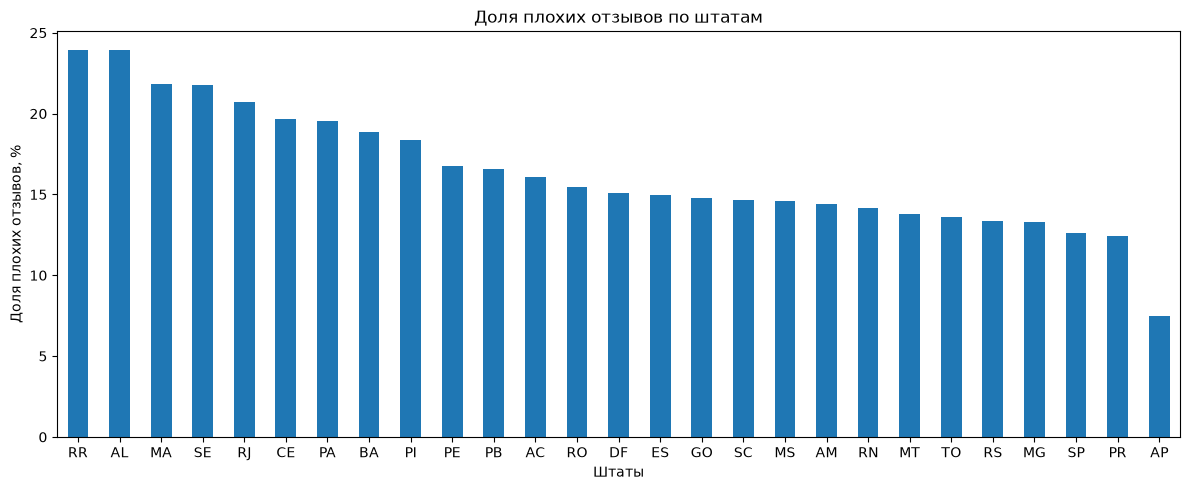

In [140]:
reviews_by_state["bad_review_rate"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Доля плохих отзывов по штатам")
plt.xlabel("Штаты")
plt.ylabel("Доля плохих отзывов, %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

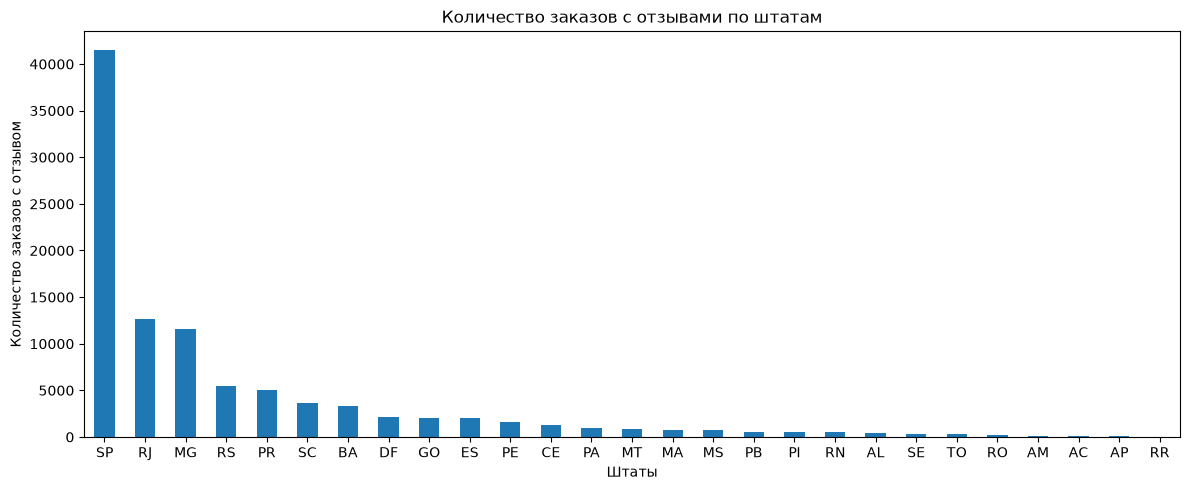

In [141]:
reviews_by_state["reviewed_orders_count"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Количество заказов с отзывами по штатам")
plt.xlabel("Штаты")
plt.ylabel("Количество заказов с отзывом")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [142]:
reviews_by_city = (
    reviewed_orders
    .groupby("customer_city")
    .agg(
        reviewed_orders_count=("bad_review", "size"),
        bad_reviews_count=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean")
    )
)

reviews_by_city["bad_review_rate"] *= 100

In [143]:
top_cities = (
    reviews_by_city
    .nlargest(20, "reviewed_orders_count")
    .sort_values("bad_review_rate", ascending=False)
)

top_cities

,reviewed_orders_count,bad_reviews_count,bad_review_rate
customer_city,,,
salvador,1219,276.0,22.641509
fortaleza,648,142.0,21.913580
rio de janeiro,6797,1386.0,20.391349
niteroi,842,163.0,19.358670
recife,605,117.0,19.338843
florianopolis,564,96.0,17.021277
porto alegre,1371,233.0,16.994894
goiania,680,114.0,16.764706
brasilia,2119,319.0,15.054271


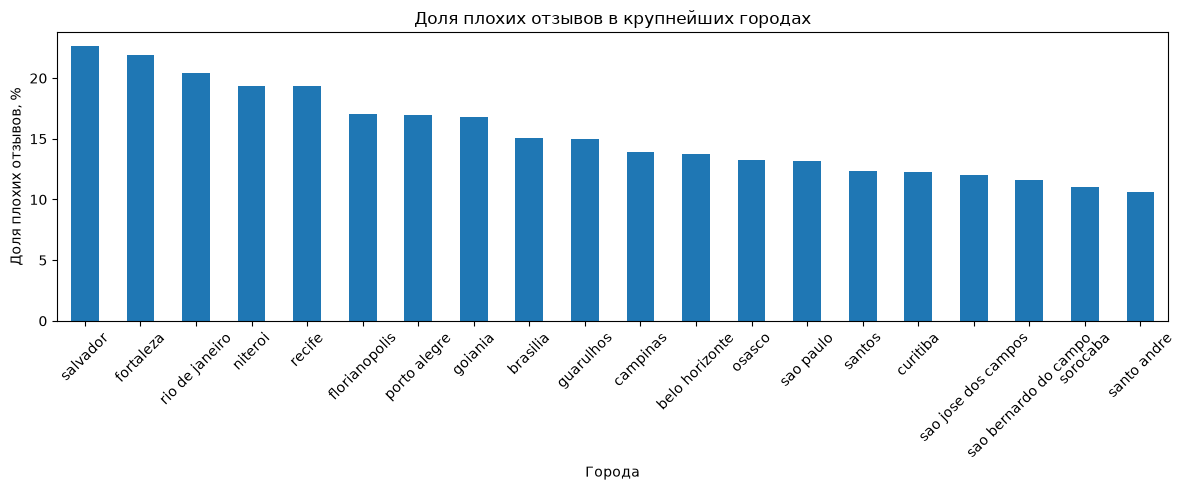

In [144]:
top_cities["bad_review_rate"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Доля плохих отзывов в крупнейших городах")
plt.xlabel("Города")
plt.ylabel("Доля плохих отзывов, %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Доля плохих отзывов заметно различается между регионами. Наибольшие значения наблюдаются в RR и AL — около 24%, однако для RR выборка очень мала (46 заказов с отзывами), поэтому этот результат следует интерпретировать осторожно. Среди штатов с крупным числом наблюдений особенно выделяется RJ с долей плохих отзывов около 20,7%, тогда как в крупнейшем по числу заказов штате SP она заметно ниже — около 12,6%. Среди крупнейших городов самые высокие значения наблюдаются в Salvador (22,6%), Fortaleza (21,9%) и Rio de Janeiro (20,4%). Таким образом, качество клиентского опыта имеет выраженные географические различия, но при сравнении регионов необходимо учитывать размер выборки.

## 4.12. Распределение таргета

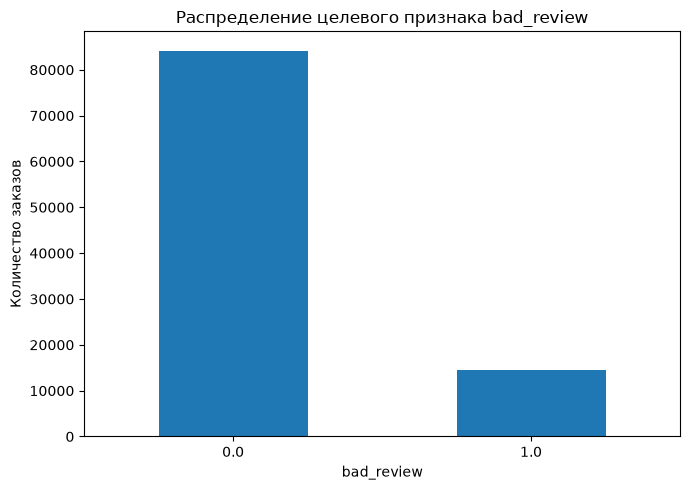

In [145]:
target_distribution = (
    orders_analytics["bad_review"]
    .dropna()
    .value_counts()
    .sort_index()
)

target_distribution.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Распределение целевого признака bad_review")
plt.xlabel("bad_review")
plt.ylabel("Количество заказов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [146]:
orders_analytics["bad_review"].dropna().value_counts(normalize=True) * 100

bad_review
0.0    85.311078
1.0    14.688922
Name: proportion, dtype: float64

Целевой признак bad_review несбалансирован: около 14,7% заказов с известной оценкой относятся к классу плохих отзывов, а около 85,3% — к классу неплохих. Данный дисбаланс необходимо учитывать при дальнейшем анализе и построении модели.

## 4.13 Связь доставки с bad_review

### 4.13.1. Сравнение характеристик доставки

In [147]:
delivery_features = [
    "delivery_time_days",
    "delivery_delay_days",
    "delay_days",
    "early_delivery_days",
    "carrier_handoff_time_days",
    "approval_time_days"
]

In [148]:
compare_by_bad_review(reviewed_orders, "delivery_time_days")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,83554,11.387244,9.874786,6.420958,14.557685
1.0,12276,20.208444,15.718848,8.960188,28.560440


In [149]:
compare_by_bad_review(reviewed_orders, "delay_days")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,83554,0.257292,0.0,0.0,0.000000
1.0,12276,4.144708,0.0,0.0,5.598744


In [150]:
compare_by_bad_review(reviewed_orders, "early_delivery_days")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,83554,12.468572,12.188223,7.212772,16.383608
1.0,12276,8.588196,7.247106,0.000000,14.126814


In [151]:
compare_by_bad_review(reviewed_orders, "carrier_handoff_time_days")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,82657,2.656493,1.785926,0.879271,3.439687
1.0,12906,4.110469,2.359751,1.072199,4.802995


In [152]:
compare_by_bad_review(reviewed_orders, "approval_time_days")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84103,0.424488,0.014213,0.008958,0.596181
1.0,14415,0.488511,0.014896,0.009005,0.670191


In [153]:
reviewed_orders.groupby("bad_review")[delivery_features].median().T

bad_review,0.0,1.0
delivery_time_days,9.874786,15.718848
delivery_delay_days,-12.188223,-7.247106
delay_days,0.000000,0.000000
early_delivery_days,12.188223,7.247106
carrier_handoff_time_days,1.785926,2.359751
approval_time_days,0.014213,0.014896


### 4.13.2. Сравнение распределений

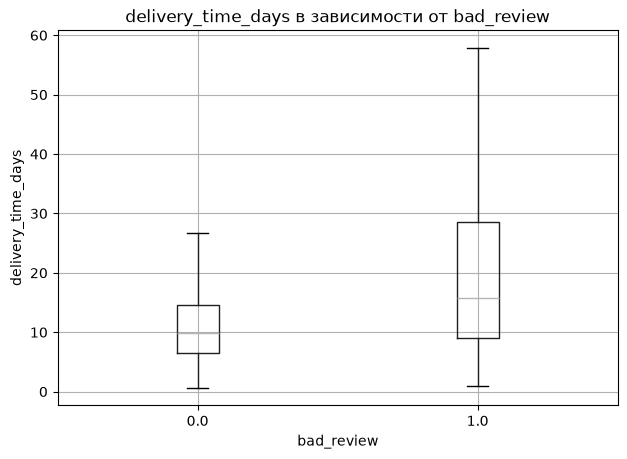

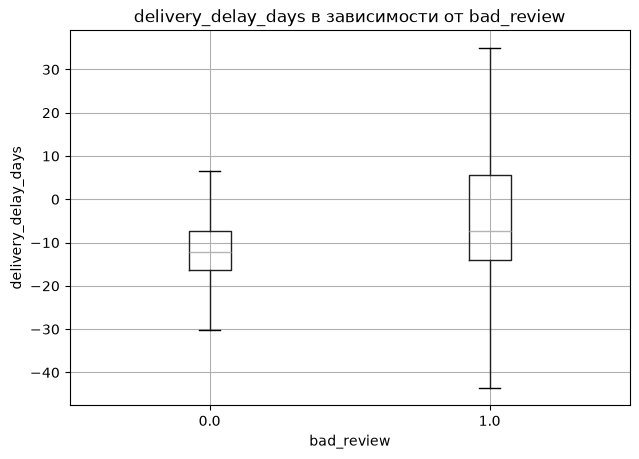

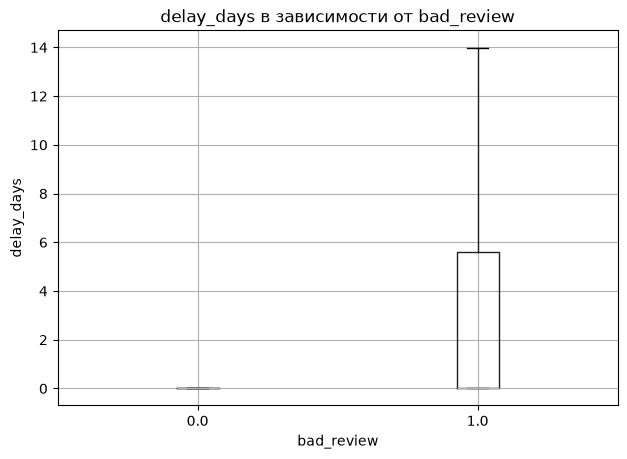

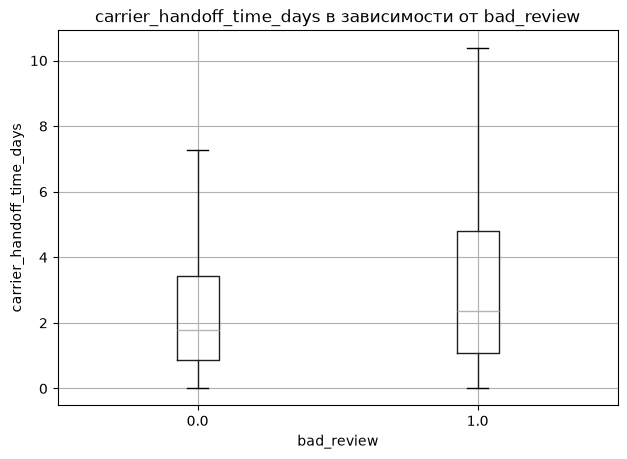

In [154]:
boxplot_features = [
    "delivery_time_days",
    "delivery_delay_days",
    "delay_days",
    "carrier_handoff_time_days",
]

for column in boxplot_features:
    reviewed_orders.boxplot(
        column=column,
        by="bad_review",
        showfliers=False,
        figsize=(7, 5)
    )

    plt.title(f"{column} в зависимости от bad_review")
    plt.suptitle("")
    plt.xlabel("bad_review")
    plt.ylabel(column)
    plt.show()

### 4.13.3. Главная проверка — опоздал заказ или нет

In [155]:
late_review = (
    reviewed_orders
    .groupby("is_late_delivery")
    .agg(
        orders_count=("bad_review", "size"),
        bad_reviews_count=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean")
    )
)

late_review["bad_review_rate"] *= 100

late_review

,orders_count,bad_reviews_count,bad_review_rate
is_late_delivery,,,
False,88168,8134.0,9.225569
True,7662,4142.0,54.058992


In [156]:
pd.crosstab(
    reviewed_orders["is_late_delivery"],
    reviewed_orders["bad_review"],
    normalize="index"
) * 100

bad_review,0.0,1.0
is_late_delivery,,
False,90.774431,9.225569
True,45.941008,54.058992


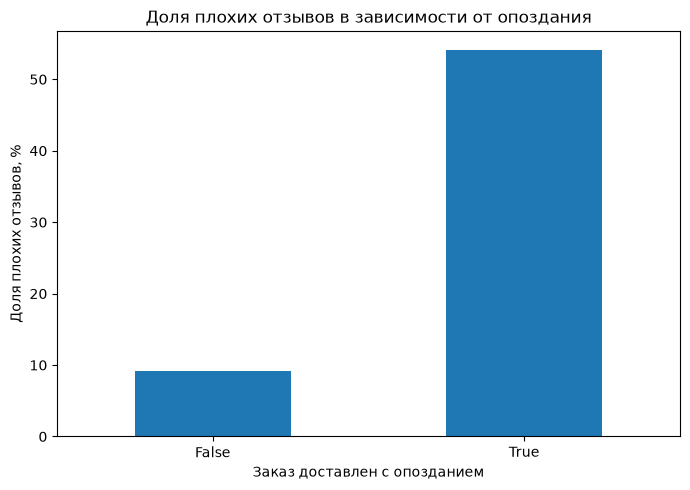

In [157]:
late_review["bad_review_rate"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Доля плохих отзывов в зависимости от опоздания")
plt.xlabel("Заказ доставлен с опозданием")
plt.ylabel("Доля плохих отзывов, %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.13.4. Насколько величина опоздания связана с плохим отзывом

In [158]:
reviewed_orders["delay_group"] = np.select(
    [
        reviewed_orders["is_late_delivery"].eq(False),

        reviewed_orders["is_late_delivery"].eq(True)
        & reviewed_orders["delay_days"].le(2),

        reviewed_orders["is_late_delivery"].eq(True)
        & reviewed_orders["delay_days"].gt(2)
        & reviewed_orders["delay_days"].le(7),

        reviewed_orders["is_late_delivery"].eq(True)
        & reviewed_orders["delay_days"].gt(7)
        & reviewed_orders["delay_days"].le(14),

        reviewed_orders["is_late_delivery"].eq(True)
        & reviewed_orders["delay_days"].gt(14)
    ],
    [
        "без опоздания",
        "до 2 дней",
        "2–7 дней",
        "7–14 дней",
        "более 14 дней"
    ],
    default=None
)

In [159]:
delay_review = (
    reviewed_orders
    .dropna(subset=["delay_group", "bad_review"])
    .groupby("delay_group")
    .agg(
        orders_count=("bad_review", "size"),
        bad_reviews_count=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean")
    )
)

delay_review["bad_review_rate"] *= 100

delay_review = delay_review.sort_values(by="bad_review_rate")

delay_review

,orders_count,bad_reviews_count,bad_review_rate
delay_group,,,
без опоздания,88168,8134.0,9.225569
до 2 дней,2100,320.0,15.238095
2–7 дней,2309,1271.0,55.045474
7–14 дней,1749,1366.0,78.101772
более 14 дней,1504,1185.0,78.789894


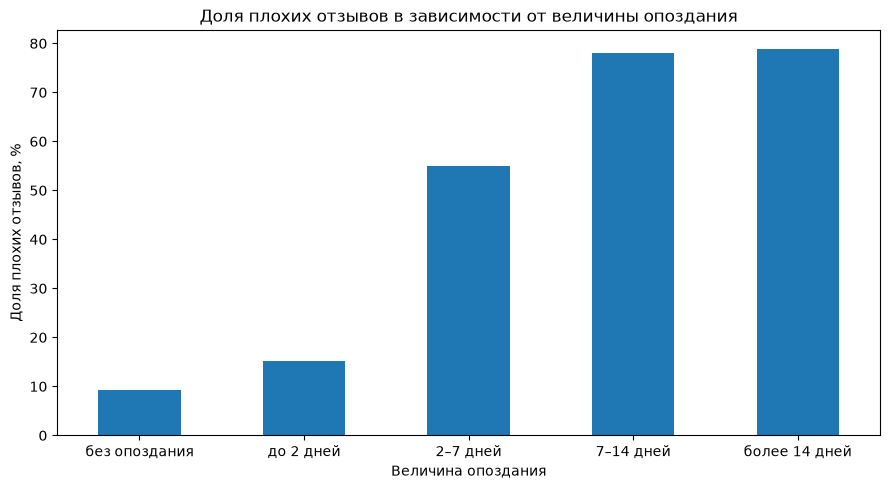

In [160]:
delay_review["bad_review_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Доля плохих отзывов в зависимости от величины опоздания")
plt.xlabel("Величина опоздания")
plt.ylabel("Доля плохих отзывов, %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Доля плохих отзывов резко возрастает с увеличением срока опоздания. Среди заказов без опоздания она составляет около 9,2%, при задержке до 2 дней — 15,2%, при задержке 2–7 дней — уже 55,0%. Для задержек 7–14 дней и более 14 дней доля плохих отзывов достигает примерно 78%. Таким образом, наблюдается сильная связь между величиной опоздания и вероятностью плохого отзыва: особенно заметный рост происходит при задержке более двух дней. При больших задержках доля плохих отзывов выходит на уровень около 78%.

## 4.14. Связь стоимости заказа с bad_review

### 4.14.1. Сравнение характеристик стоимости заказа

In [161]:
compare_by_bad_review(orders_analytics, "order_total")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,155.545024,103.15,60.86,172.84
1.0,13893,189.327758,118.22,68.12,203.10


In [162]:
compare_by_bad_review(orders_analytics, "total_price")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,133.501997,84.9,45.0,149.0
1.0,13893,161.921342,98.0,49.9,170.0


In [163]:
compare_by_bad_review(orders_analytics, "total_freight")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,22.043027,16.94,13.65,23.38
1.0,13893,27.406415,18.30,15.09,30.46


In [164]:
compare_by_bad_review(orders_analytics, "freight_ratio")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,0.208247,0.183097,0.116500,0.274594
1.0,13893,0.212392,0.186946,0.116974,0.280606


In [165]:
compare_by_bad_review(orders_analytics, "mean_item_price")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,124.155045,79.0,41.3,139.0
1.0,13893,135.322360,79.9,44.9,146.0


In [166]:
compare_by_bad_review(orders_analytics, "max_item_price")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,124.644629,79.00,41.9,139.9
1.0,13893,137.372688,81.56,45.0,149.0


По результатам сравнения видно, что заказы с плохими отзывами в среднем имеют несколько более высокую стоимость. Медиана order_total увеличивается с 103,15 до 118,22, а total_price — с 84,9 до 98,0. Также заметно выше стоимость доставки: медиана total_freight возрастает с 16,94 до 18,30, при этом различие особенно выражено в верхней части распределения (q75: 23,38 против 30,46).

Для mean_item_price и max_item_price различия между группами значительно слабее, а распределение freight_ratio практически не меняется. Таким образом, более высокая общая стоимость заказа и доставки связана с большей долей плохих отзывов, однако эта связь заметно слабее, чем ранее обнаруженная связь bad_review с опозданием доставки.

### 4.14.2. Сравнение распределений

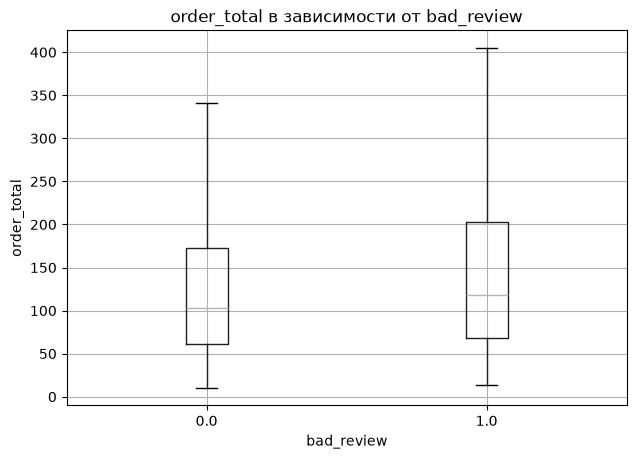

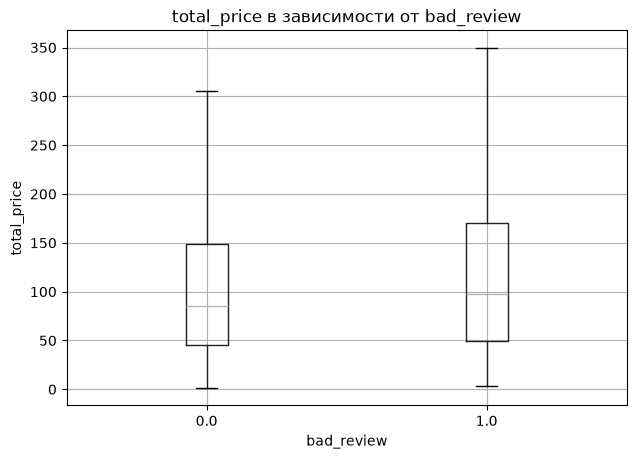

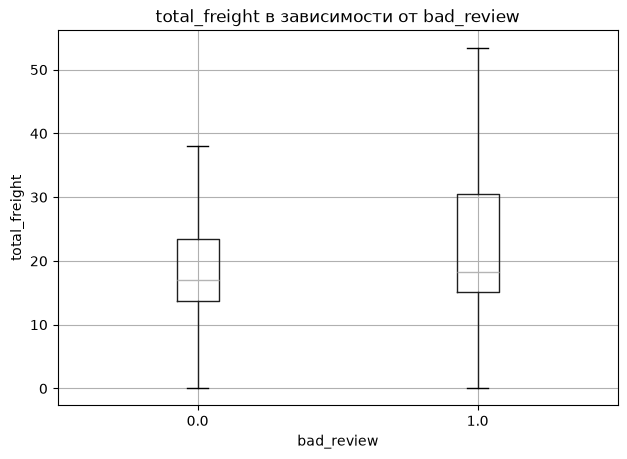

In [167]:
boxplot_features = [
    "order_total", 
    "total_price",
    "total_freight"
]

for column in boxplot_features:
    orders_analytics.boxplot(
        column=column,
        by="bad_review",
        showfliers=False,
        figsize=(7, 5)
    )

    plt.title(f"{column} в зависимости от bad_review")
    plt.suptitle("")
    plt.xlabel("bad_review")
    plt.ylabel(column)
    plt.show()
    

### 4.14.3. Насколько величина стоимости заказа связана с плохим отзывом

In [168]:
orders_analytics["price_group"] = np.select(
    [
        orders_analytics["order_total"].gt(0) & orders_analytics["order_total"].le(50),
        orders_analytics["order_total"].gt(50) & orders_analytics["order_total"].le(120),
        orders_analytics["order_total"].gt(120) & orders_analytics["order_total"].le(200),
        orders_analytics["order_total"].gt(200) & orders_analytics["order_total"].le(300),
        orders_analytics["order_total"].gt(300)
    ],
    [
        "0-50",
        "50-120",
        "120-200",
        "200-300",
        "более 300"
    ],
    default=None
)

In [169]:
price_review = (
    orders_analytics.dropna(subset=["price_group", "bad_review"])
    .groupby("price_group")
    .agg(
        orders_count = ("bad_review", "size"),
        bad_review_count = ("bad_review", "sum"),
        bad_review_rate = ("bad_review", "mean")
    )
)

price_review["bad_review_rate"] *= 100

price_review = price_review.sort_values(by="bad_review_rate")

price_review

,orders_count,bad_review_count,bad_review_rate
price_group,,,
0-50,16757,1904.0,11.362416
50-120,38933,5135.0,13.189325
120-200,22318,3297.0,14.772829
200-300,9789,1656.0,16.916948
более 300,10120,1901.0,18.784585


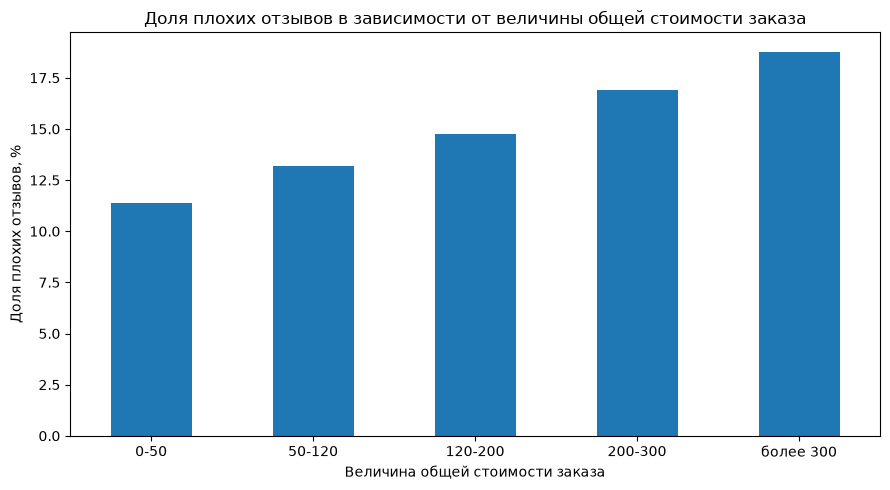

In [170]:
price_review["bad_review_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Доля плохих отзывов в зависимости от величины общей стоимости заказа")
plt.xlabel("Величина общей стоимости заказа")
plt.ylabel("Доля плохих отзывов, %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Наблюдается последовательное увеличение доли плохих отзывов с ростом общей стоимости заказа. Для заказов стоимостью до 50 доля bad_review составляет около 11,4%, тогда как для заказов дороже 300 она возрастает до 18,8%. Промежуточные ценовые группы также демонстрируют постепенный рост доли плохих отзывов. Таким образом, между стоимостью заказа и вероятностью плохого отзыва наблюдается положительная связь: более дорогие заказы чаще получают плохие отзывы. При этом данный результат отражает связь между признаками и сам по себе не доказывает причинно-следственную зависимость.

## 4.15. Связь сложности заказа с bad_review

### 4.15.1. Сравнение характеристик сложности заказа

In [171]:
compare_by_bad_review(orders_analytics, "items_count")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,1.115431,1.0,1.0,1.0
1.0,13893,1.294537,1.0,1.0,1.0


In [172]:
compare_by_bad_review(orders_analytics, "products_count")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,1.028801,1.0,1.0,1.0
1.0,13893,1.092924,1.0,1.0,1.0


In [173]:
compare_by_bad_review(orders_analytics, "sellers_count")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,1.008176,1.0,1.0,1.0
1.0,13893,1.046282,1.0,1.0,1.0


In [174]:
compare_by_bad_review(orders_analytics, "categories_count")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,0.991752,1.0,1.0,1.0
1.0,13893,1.003743,1.0,1.0,1.0


In [175]:
compare_by_bad_review(orders_analytics, "has_multiple_products")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,0.025017,0.0,0.0,0.0
1.0,13893,0.078817,0.0,0.0,0.0


In [176]:
compare_by_bad_review(orders_analytics, "has_multiple_sellers")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84024,0.007926,0.0,0.0,0.0
1.0,13893,0.043043,0.0,0.0,0.0


In [177]:
orders_analytics["multiple_items"] = (
    orders_analytics["items_count"] > 1
)

In [178]:
orders_analytics.groupby("multiple_items")["bad_review"].mean() * 100

multiple_items
False    13.275569
True     27.667699
Name: bad_review, dtype: float64

In [179]:
orders_analytics.groupby("has_multiple_sellers")["bad_review"].mean() * 100

has_multiple_sellers
0.0    13.755393
1.0    47.310127
Name: bad_review, dtype: float64

In [180]:
orders_analytics.groupby("has_multiple_products")["bad_review"].mean() * 100

has_multiple_products
0.0    13.511402
1.0    34.250860
Name: bad_review, dtype: float64

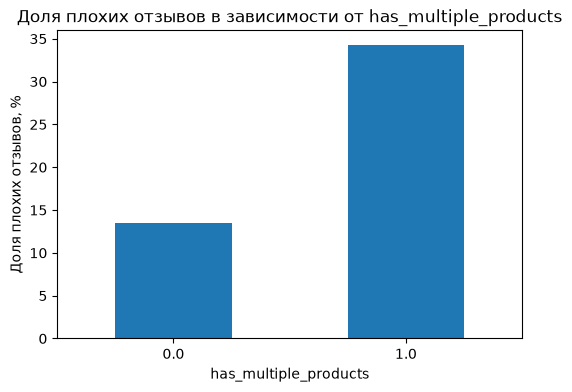

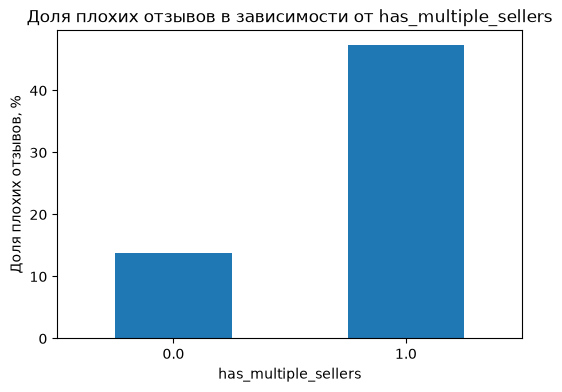

In [181]:
complexity_features = [
    "has_multiple_products",
    "has_multiple_sellers"
]

for col in complexity_features:
    (
        orders_analytics
        .groupby(col)["bad_review"]
        .mean()
        .mul(100)
        .plot(kind="bar", figsize=(6,4))
    )

    plt.ylabel("Доля плохих отзывов, %")
    plt.title(f"Доля плохих отзывов в зависимости от {col}")
    plt.xticks(rotation=0)
    plt.show()

По результатам анализа можно сделать вывод, что сложность заказа оказывает заметное влияние на вероятность получения плохого отзыва.

Заказы с несколькими товарами (has_multiple_products = 1) имеют значительно большую долю плохих отзывов — 34,26%, тогда как для обычных заказов этот показатель составляет 13,51%. Это может быть связано с тем, что при наличии нескольких товаров увеличивается вероятность возникновения проблем с комплектацией, упаковкой или качеством отдельных позиций.

Ещё более выраженная зависимость наблюдается для заказов с несколькими продавцами (has_multiple_sellers = 1): доля плохих отзывов составляет 47,31%, в то время как для заказов от одного продавца — 13,76%. Вероятно, это связано с усложнением процесса доставки и координации нескольких отправлений.

Таким образом, увеличение сложности заказа связано с ростом количества негативных отзывов. Наиболее сильное влияние оказывает наличие нескольких продавцов, так как такие заказы требуют более сложной логистики и могут чаще приводить к задержкам или ошибкам при выполнении заказа. Для дальнейшего анализа целесообразно учитывать признаки сложности заказа при построении моделей прогнозирования вероятности плохого отзыва.

## 4.16. Сравнение физических характеристик с bad_review

In [182]:
compare_by_bad_review(orders_analytics, "total_weight_g")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84011,2287.891455,710.0,300.0,1950.0
1.0,13890,2986.991361,850.0,346.0,2600.0


In [183]:
compare_by_bad_review(orders_analytics, "total_volume_cm3")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84011,16674.093571,7038.0,2912.0,19800.0
1.0,13890,21590.807559,8077.0,3136.0,23625.0


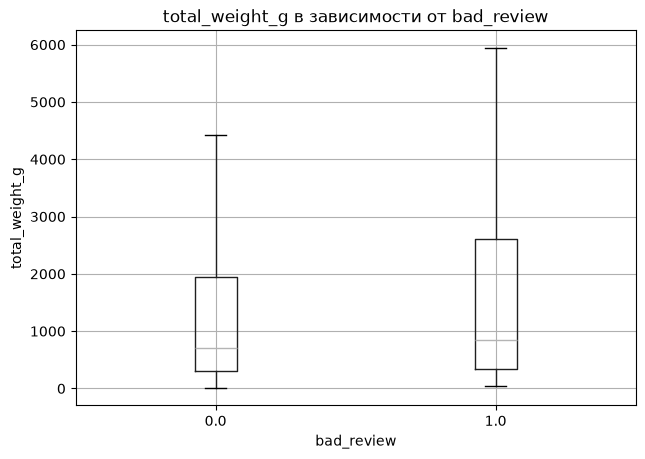

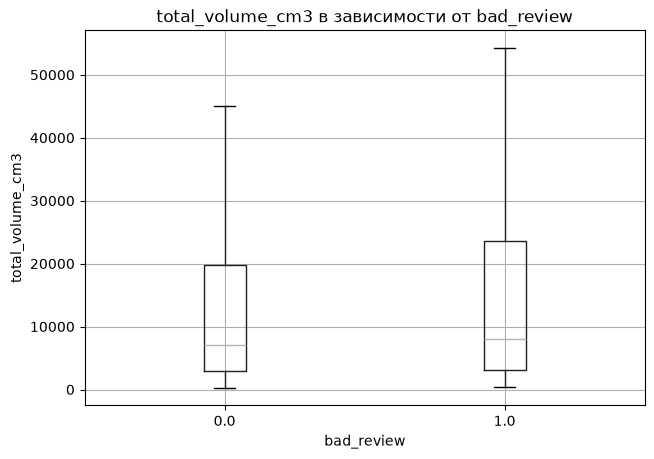

In [184]:
boxplot_features = [
    "total_weight_g", 
    "total_volume_cm3",
]

for column in boxplot_features:
    orders_analytics.boxplot(
        column=column,
        by="bad_review",
        showfliers=False,
        figsize=(7, 5)
    )

    plt.title(f"{column} в зависимости от bad_review")
    plt.suptitle("")
    plt.xlabel("bad_review")
    plt.ylabel(column)
    plt.show()

### Анализ доли плохих отзывов в зависимости от физических характеристик

In [185]:
orders_analytics["weight_group"] = pd.qcut(
    orders_analytics["total_weight_g"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

orders_analytics.groupby("weight_group")["bad_review"].mean() * 100

weight_group
Q1    12.962529
Q2    13.344757
Q3    13.835033
Q4    16.644828
Name: bad_review, dtype: float64

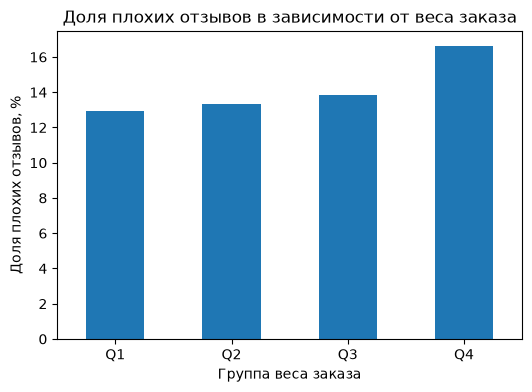

In [186]:
(
    orders_analytics
    .groupby("weight_group")["bad_review"]
    .mean()
    .mul(100)
    .plot(kind="bar", figsize=(6,4))
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("Группа веса заказа")
plt.title("Доля плохих отзывов в зависимости от веса заказа")
plt.xticks(rotation=0)
plt.show()

In [187]:
orders_analytics["volume_group"] = pd.qcut(
    orders_analytics["total_volume_cm3"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

orders_analytics.groupby("volume_group")["bad_review"].mean() * 100

volume_group
Q1    13.304616
Q2    12.997869
Q3    13.687048
Q4    16.770466
Name: bad_review, dtype: float64

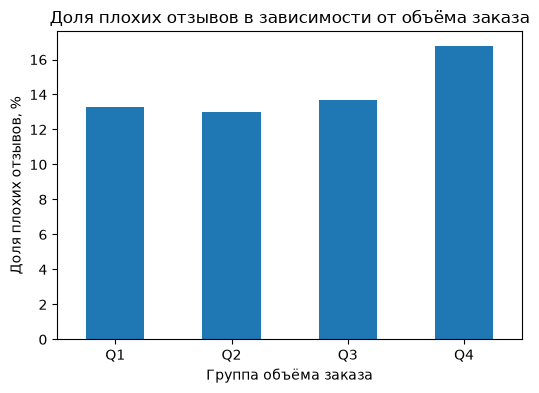

In [188]:
(
    orders_analytics
    .groupby("volume_group")["bad_review"]
    .mean()
    .mul(100)
    .plot(kind="bar", figsize=(6,4))
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("Группа объёма заказа")
plt.title("Доля плохих отзывов в зависимости от объёма заказа")
plt.xticks(rotation=0)
plt.show()

Анализ зависимости доли плохих отзывов от физических характеристик заказа показал, что увеличение веса и объёма заказа связано с некоторым ростом вероятности получения плохого отзыва. Для веса заказа доля плохих отзывов увеличивается от 12.96% в первой квартильной группе до 16.64% в четвёртой, то есть для самых тяжёлых заказов вероятность негативной оценки выше примерно на 3.7 процентных пункта. Аналогичная тенденция наблюдается для объёма заказа: доля плохих отзывов возрастает с 13.30% в группе заказов с наименьшим объёмом до 16.77% в группе с максимальным объёмом.

При этом зависимость не является строго линейной: в средних группах показатели изменяются незначительно, а заметный рост наблюдается преимущественно для наиболее крупных и тяжёлых заказов. Это может свидетельствовать о том, что сложные по физическим характеристикам заказы чаще сталкиваются с проблемами доставки, упаковки или обработки, что увеличивает вероятность возникновения негативного пользовательского опыта.

Таким образом, физические характеристики заказа могут рассматриваться как один из факторов, связанных с появлением плохих отзывов, однако их влияние является умеренным и требует дополнительного анализа совместно с другими характеристиками заказа.

## 4.17. Связь платёжных характеристик с bad_review

### Числовые характеристики

In [189]:
compare_by_bad_review(orders_analytics, "max_installments")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84179,2.888369,2.0,1.0,4.0
1.0,14493,3.158904,2.0,1.0,4.0


In [190]:
compare_by_bad_review(orders_analytics, "payments_count")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84179,1.043930,1.0,1.0,1.0
1.0,14493,1.049403,1.0,1.0,1.0


In [191]:
compare_by_bad_review(orders_analytics, "payment_types_count")

,count,mean,median,q25,q75
bad_review,,,,,
0.0,84179,1.022595,1.0,1.0,1.0
1.0,14493,1.022425,1.0,1.0,1.0


In [192]:
orders_analytics["installments_group"] = pd.qcut(
    orders_analytics["max_installments"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

orders_analytics.groupby("installments_group")["bad_review"].mean() * 100

installments_group
Q1    13.839509
Q2    13.897946
Q3    15.208753
Q4    16.645351
Name: bad_review, dtype: float64

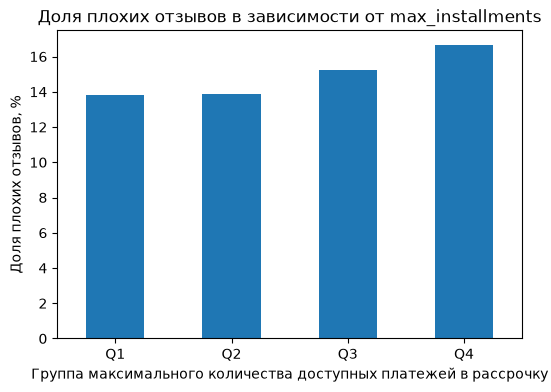

In [193]:
(
    orders_analytics
    .groupby("installments_group")["bad_review"]
    .mean()
    .mul(100)
    .plot(kind="bar", figsize=(6,4))
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("Группа максимального количества доступных платежей в рассрочку")
plt.title("Доля плохих отзывов в зависимости от max_installments")
plt.xticks(rotation=0)
plt.show()

### Категориальные характеристики

In [194]:
orders_analytics.groupby("main_payment_type")["bad_review"].mean() * 100

main_payment_type
boleto         14.422489
credit_card    14.704577
debit_card     13.017751
not_defined    66.666667
voucher        16.703575
Name: bad_review, dtype: float64

In [195]:
orders_analytics.groupby("used_installments")["bad_review"].mean() * 100

used_installments
0.0    13.839509
1.0    15.489516
Name: bad_review, dtype: float64

In [196]:
orders_analytics.groupby("has_multiple_payment_types")["bad_review"].mean() * 100

has_multiple_payment_types
0.0    14.690238
1.0    14.593624
Name: bad_review, dtype: float64

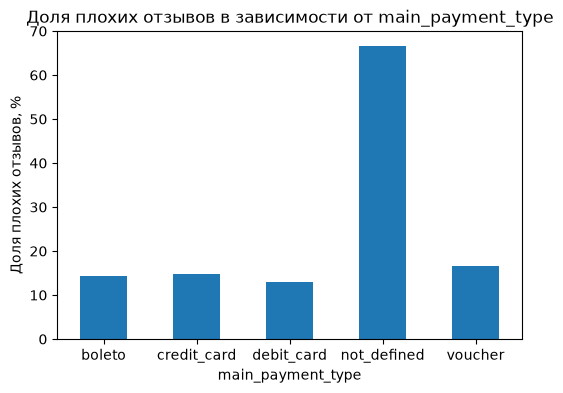

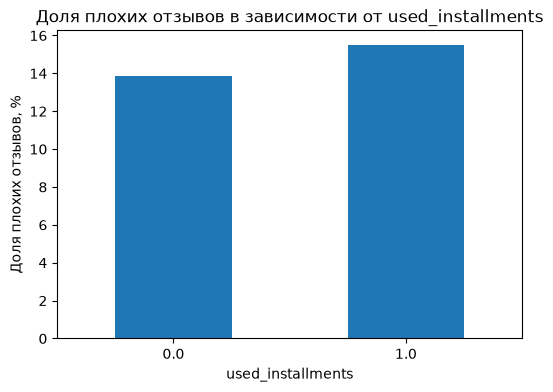

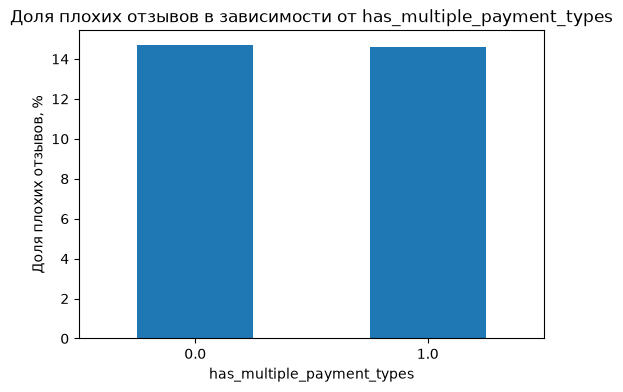

In [197]:
complexity_features = [
    "main_payment_type",
    "used_installments",
    "has_multiple_payment_types"
]

for col in complexity_features:
    (
        orders_analytics
        .groupby(col)["bad_review"]
        .mean()
        .mul(100)
        .plot(kind="bar", figsize=(6,4))
    )

    plt.ylabel("Доля плохих отзывов, %")
    plt.title(f"Доля плохих отзывов в зависимости от {col}")
    plt.xticks(rotation=0)
    plt.show()

В ходе анализа связи платёжных характеристик с наличием плохого отзыва было установлено, что большинство платёжных признаков имеют слабую зависимость от bad_review.

Для признака max_installments наблюдается небольшое увеличение доли плохих отзывов при увеличении количества доступных платежей в рассрочку: от 13.8% в группе с меньшим количеством рассрочек до 16.6% в группе с максимальными значениями. Это может указывать на слабую связь между использованием рассрочки и вероятностью негативной оценки заказа.

Количество платежей (payments_count) и количество типов оплаты (payment_types_count) практически не отличаются между группами заказов с хорошими и плохими отзывами, поэтому существенного влияния данных признаков выявлено не было.

Среди категориальных признаков наиболее заметное отличие наблюдается для main_payment_type. Однако высокая доля плохих отзывов для категории not_defined (66.7%) связана, вероятнее всего, с отсутствием информации о способе оплаты, поэтому данный результат нельзя интерпретировать как влияние конкретного способа оплаты.

Использование рассрочки (used_installments) также показывает небольшое увеличение доли плохих отзывов: 13.8% без рассрочки против 15.5% при использовании рассрочки. Однако различие является незначительным.

Таким образом, платёжные характеристики заказа не оказывают существенного влияния на вероятность получения плохого отзыва. Наиболее выраженная зависимость наблюдается только для заказов с большим количеством доступных платежей в рассрочку, однако её сила остаётся небольшой.

## 4.18. Связь времени покупки с bad_review

In [198]:
orders_analytics.groupby("purchase_day_of_week")["bad_review"].mean() * 100

purchase_day_of_week
0    14.599950
1    14.647070
2    14.122682
3    14.531314
4    15.790975
5    14.888683
6    14.312158
Name: bad_review, dtype: float64

In [199]:
orders_analytics.groupby("purchase_hour")["bad_review"].mean() * 100

purchase_hour
0     17.032967
1     17.631806
2     17.261905
3     11.567164
4     18.048780
5     14.438503
6     17.269076
7     13.970588
8     12.974255
9     13.765523
10    14.808163
11    14.469257
12    15.460969
13    14.524104
14    14.532925
15    14.959400
16    14.279245
17    14.290397
18    15.321454
19    15.509103
20    14.488035
21    14.454899
22    13.463871
23    15.145584
Name: bad_review, dtype: float64

In [200]:
orders_analytics.groupby("purchase_is_weekend")["bad_review"].mean() * 100

purchase_is_weekend
False    14.719503
True     14.586367
Name: bad_review, dtype: float64

In [201]:
orders_analytics.groupby("purchase_year_month")["bad_review"].mean() * 100

purchase_year_month
2016-09    100.000000
2016-10     29.153605
2016-12      0.000000
2017-01     15.569620
2017-02     16.176471
2017-03     14.167606
2017-04     15.458735
2017-05     12.765957
2017-06     12.740833
2017-07     12.205514
2017-08     11.354118
2017-09     12.444131
2017-10     13.237535
2017-11     18.770053
2017-12     16.393443
2018-01     15.511734
2018-02     20.893285
2018-03     22.789591
2018-04     12.988522
2018-05     11.902325
2018-06     10.780003
2018-07     11.109332
2018-08     10.932922
2018-09     80.000000
2018-10     75.000000
Freq: M, Name: bad_review, dtype: float64

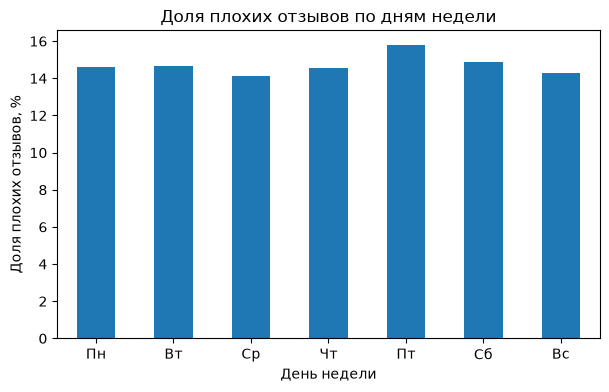

In [202]:
day_bad_review = (
    orders_analytics
    .groupby("purchase_day_of_week")["bad_review"]
    .mean()
    .mul(100)
)

day_bad_review.index = [
    "Пн",
    "Вт",
    "Ср",
    "Чт",
    "Пт",
    "Сб",
    "Вс"
]

day_bad_review.plot(
    kind="bar",
    figsize=(7,4)
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("День недели")
plt.title("Доля плохих отзывов по дням недели")

plt.xticks(rotation=0)

plt.show()

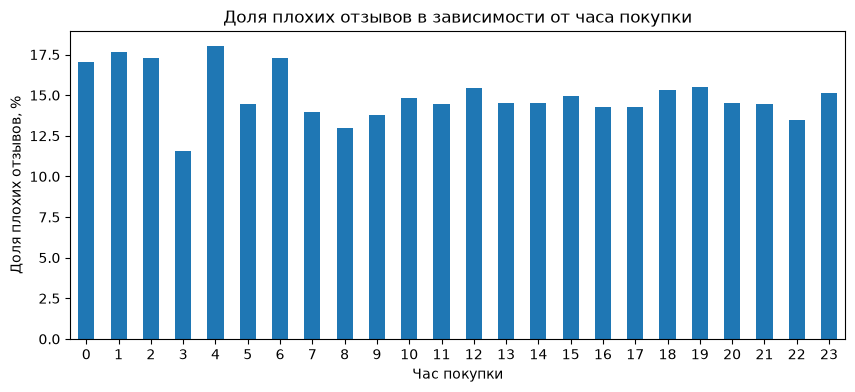

In [203]:
hour_bad_review = (
    orders_analytics
    .groupby("purchase_hour")["bad_review"]
    .mean()
    .mul(100)
)

hour_bad_review.plot(
    kind="bar",
    figsize=(10, 4)
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("Час покупки")
plt.title("Доля плохих отзывов в зависимости от часа покупки")

plt.xticks(rotation=0)

plt.show()

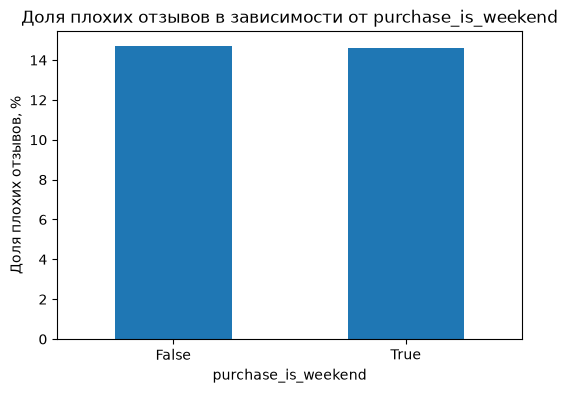

In [204]:
weekend_bad_review = (
    orders_analytics
    .groupby("purchase_is_weekend")["bad_review"]
    .mean()
    .mul(100)
)

weekend_bad_review.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("purchase_is_weekend")
plt.title("Доля плохих отзывов в зависимости от purchase_is_weekend")

plt.xticks(rotation=0)

plt.show()

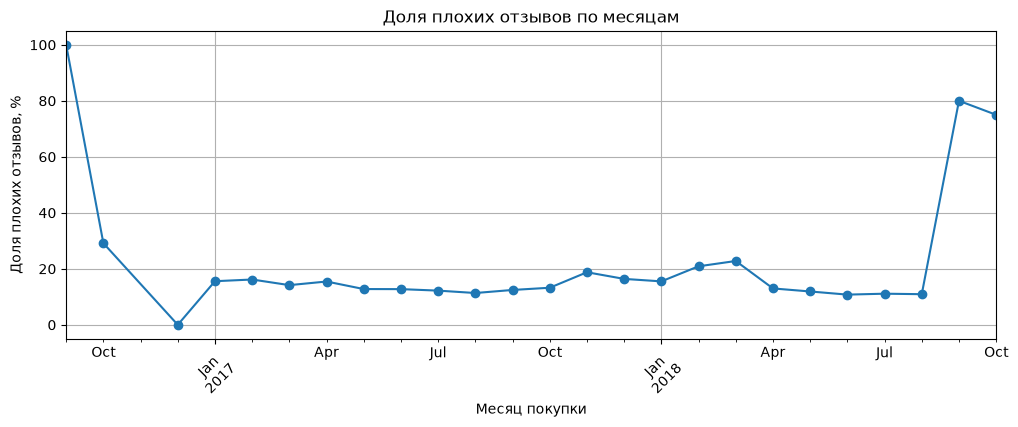

In [205]:
monthly_bad_review = (
    orders_analytics
    .groupby("purchase_year_month")["bad_review"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(12,4))

monthly_bad_review.plot(
    marker="o"
)

plt.ylabel("Доля плохих отзывов, %")
plt.xlabel("Месяц покупки")
plt.title("Доля плохих отзывов по месяцам")
plt.xticks(rotation=45)

plt.grid()
plt.show()

В ходе анализа связи времени покупки с наличием плохого отзыва существенных зависимостей выявлено не было.

Доля плохих отзывов по дням недели находится примерно на одном уровне (около 14–16%), что говорит об отсутствии влияния дня покупки на вероятность негативной оценки.

Аналогичная ситуация наблюдается для покупок в выходные дни: различие между будними и выходными днями практически отсутствует.

Анализ времени суток также не показал выраженной зависимости. Значения доли плохих отзывов для разных часов отличаются незначительно и находятся примерно в одном диапазоне.

При анализе изменения по месяцам наблюдаются отдельные резкие скачки доли плохих отзывов, однако они связаны с небольшим количеством заказов в отдельных периодах, поэтому не могут рассматриваться как устойчивые закономерности.

Таким образом, временные характеристики покупки не оказывают существенного влияния на вероятность получения плохого отзыва.

## 4.19. Корреляции числовых признаков

In [206]:
corr_features = [
    # Размер заказа
    "items_count",
    "products_count",
    "sellers_count",
    "categories_count",

    # Деньги
    "order_total",
    "total_price",
    "mean_item_price",
    "max_item_price",
    "total_freight",
    "freight_ratio",

    # Физические характеристики
    "total_weight_g",
    "total_volume_cm3",

    # Доставка
    "approval_time_days",
    "carrier_handoff_time_days",
    "delivery_time_days",
    "estimated_delivery_time_days",

    # Целевая переменная
    "bad_review"
]

In [207]:
corr_matrix = orders_analytics[corr_features].corr()

corr_matrix

,items_count,products_count,sellers_count,categories_count,order_total,total_price,mean_item_price,max_item_price,total_freight,freight_ratio,total_weight_g,total_volume_cm3,approval_time_days,carrier_handoff_time_days,delivery_time_days,estimated_delivery_time_days,bad_review
items_count,1.000000,0.470977,0.282200,0.130457,0.189155,0.153063,-0.058460,-0.048008,0.436941,0.074662,0.228177,0.281916,0.025463,0.028403,-0.019113,0.015240,0.117081
products_count,0.470977,1.000000,0.592784,0.270218,0.077728,0.061311,-0.037134,-0.016393,0.194978,0.022246,0.083156,0.102574,0.002959,-0.008767,-0.029793,0.022813,0.099091
sellers_count,0.282200,0.592784,1.000000,0.362560,0.052427,0.041463,-0.020968,-0.001271,0.130456,0.008347,0.051850,0.066107,0.004933,-0.029147,-0.040558,0.023772,0.108818
categories_count,0.130457,0.270218,0.362560,1.000000,0.030474,0.024138,-0.005952,0.003991,0.075462,0.009228,0.041396,0.050771,0.005222,-0.020544,-0.018942,0.012493,0.028283
order_total,0.189155,0.077728,0.052427,0.030474,1.000000,0.995991,0.921212,0.925624,0.492603,-0.386165,0.396596,0.361205,0.025626,0.076722,0.069570,0.095966,0.053760
total_price,0.153063,0.061311,0.041463,0.024138,0.995991,1.000000,0.933169,0.937164,0.412786,-0.415741,0.349394,0.312093,0.022723,0.071185,0.055578,0.075986,0.047338
mean_item_price,-0.058460,-0.037134,-0.020968,-0.005952,0.921212,0.933169,1.000000,0.998118,0.301529,-0.436992,0.276329,0.234810,0.012541,0.066418,0.060441,0.074055,0.020545
max_item_price,-0.048008,-0.016393,-0.001271,0.003991,0.925624,0.937164,0.998118,1.000000,0.307592,-0.437078,0.279593,0.237961,0.012911,0.065687,0.059425,0.074887,0.023329
total_freight,0.436941,0.194978,0.130456,0.075462,0.492603,0.412786,0.301529,0.307592,1.000000,0.112591,0.639023,0.641530,0.039872,0.088371,0.167138,0.237913,0.086558
freight_ratio,0.074662,0.022246,0.008347,0.009228,-0.386165,-0.415741,-0.436992,-0.437078,0.112591,1.000000,-0.092495,-0.072473,0.033571,-0.024417,0.089584,0.137820,0.011506


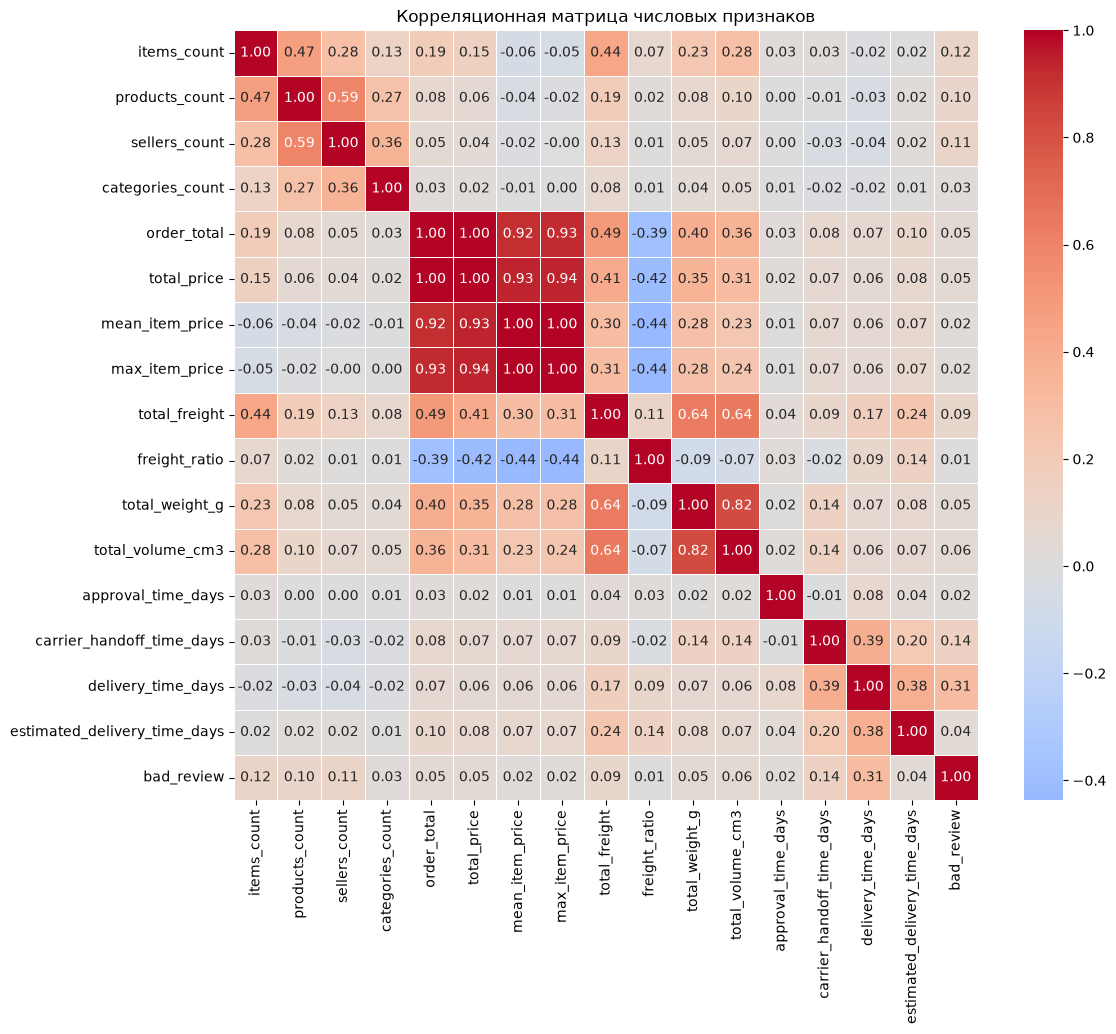

In [209]:
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Корреляционная матрица числовых признаков")

plt.show()

In [210]:
bad_review_corr = (
    corr_matrix["bad_review"]
    .sort_values(ascending=False)
)

bad_review_corr

bad_review                      1.000000
delivery_time_days              0.311608
carrier_handoff_time_days       0.142831
items_count                     0.117081
sellers_count                   0.108818
products_count                  0.099091
total_freight                   0.086558
total_volume_cm3                0.056581
order_total                     0.053760
total_weight_g                  0.051129
total_price                     0.047338
estimated_delivery_time_days    0.042798
categories_count                0.028283
max_item_price                  0.023329
approval_time_days              0.020914
mean_item_price                 0.020545
freight_ratio                   0.011506
Name: bad_review, dtype: float64

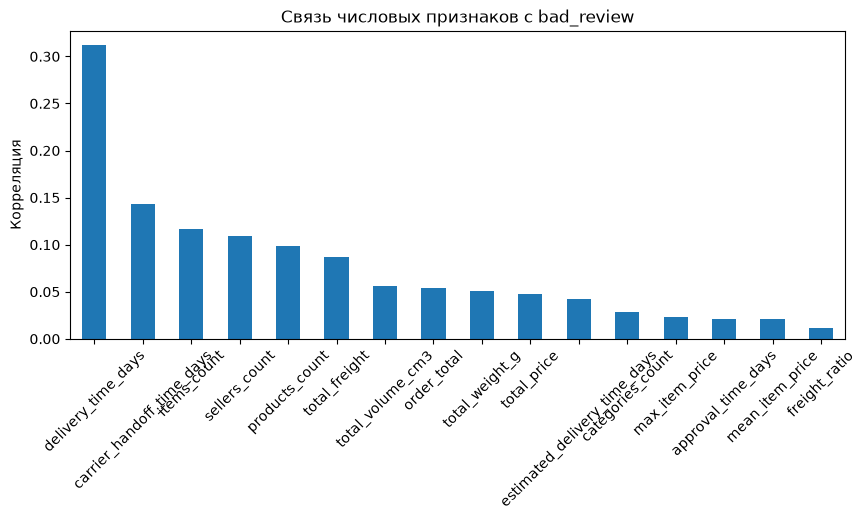

In [211]:
bad_review_corr.drop("bad_review").plot(
    kind="bar",
    figsize=(10,4)
)

plt.ylabel("Корреляция")
plt.title("Связь числовых признаков с bad_review")

plt.xticks(rotation=45)
plt.show()

В ходе анализа корреляций числовых признаков с целевой переменной bad_review было выявлено, что большинство признаков имеют слабую линейную связь с вероятностью получения плохого отзыва.

Наиболее заметная положительная корреляция наблюдается у признака `delivery_time_days` — коэффициент корреляции составляет 0.31. Это говорит о том, что увеличение срока доставки связано с ростом вероятности появления плохого отзыва: чем дольше клиент ожидает заказ, тем выше вероятность его недовольства.

Также небольшая положительная связь наблюдается у признаков:

carrier_handoff_time_days — корреляция 0.14;
items_count — корреляция 0.12;
sellers_count — корреляция 0.11;
products_count — корреляция 0.10.

Это может указывать на то, что более сложные заказы с большим количеством товаров, продавцов или этапов обработки немного чаще сопровождаются негативными отзывами.

Остальные признаки имеют очень слабую корреляцию с bad_review (|r| < 0.1), поэтому выраженного линейного влияния на наличие плохого отзыва не обнаружено. В частности, финансовые характеристики заказа (total_price, order_total, mean_item_price), физические характеристики (total_weight_g, total_volume_cm3) и параметры доставки (approval_time_days, estimated_delivery_time_days) практически не связаны с целевой переменной.

Отрицательных корреляций значительной силы также обнаружено не было, что говорит об отсутствии признаков, увеличение которых напрямую снижает вероятность плохого отзыва.

Таким образом, среди числовых признаков наиболее важным фактором, связанным с негативной оценкой клиентов, является фактическое время доставки (delivery_time_days). Для дальнейшего моделирования рекомендуется учитывать данный признак, а также признаки, связанные со сложностью заказа и количеством этапов его обработки.

## 4.20. Анализ выбросов

In [212]:
outlier_features = [
    "total_price",
    "total_freight",
    "items_count",
    "delivery_time_days",
    "carrier_handoff_time_days"
]

In [213]:
def analyze_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(f"Признак: {column}")
    print(f"Нижняя граница: {lower_bound:.2f}")
    print(f"Верхняя граница: {upper_bound:.2f}")
    print(f"Количество выбросов: {len(outliers)}")
    print(f"Доля выбросов: {len(outliers) / len(df) * 100:.2f}%")
    
    print("\nСамые большие значения:")
    display(df[column].sort_values(ascending=False).head(5))
    
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[column])
    plt.title(f"Выбросы в {column}")
    plt.show()
    
    return outliers

Признак: total_price
Нижняя граница: -110.10
Верхняя граница: 305.90
Количество выбросов: 7913
Доля выбросов: 7.96%

Самые большие значения:


13390    13440.0
66599     7160.0
22171     6735.0
28326     6729.0
3508      6499.0
Name: total_price, dtype: float64

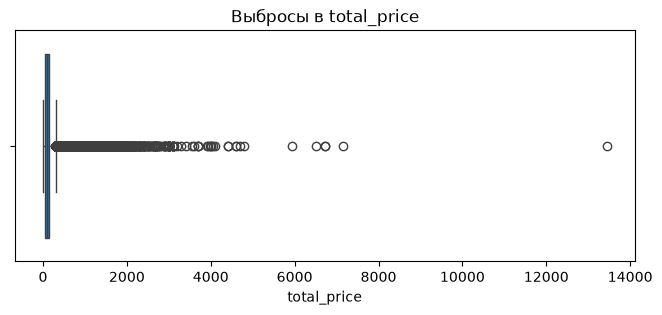

Признак: total_freight
Нижняя граница: -1.44
Верхняя граница: 39.33
Количество выбросов: 9941
Доля выбросов: 10.00%

Самые большие значения:


20074    1794.96
63700    1002.29
88772     711.33
16335     626.64
27964     502.98
Name: total_freight, dtype: float64

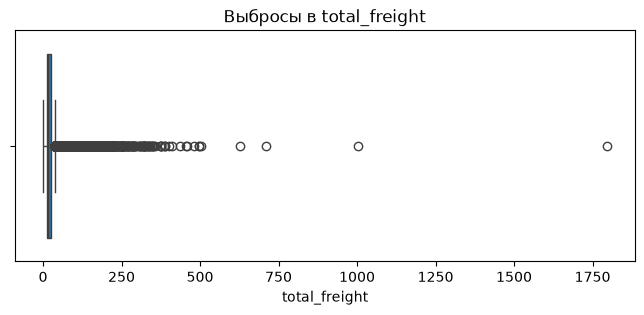

Признак: items_count
Нижняя граница: 1.00
Верхняя граница: 1.00
Количество выбросов: 9803
Доля выбросов: 9.86%

Самые большие значения:


88849    21.0
94019    20.0
86978    20.0
66435    15.0
30318    15.0
Name: items_count, dtype: float64

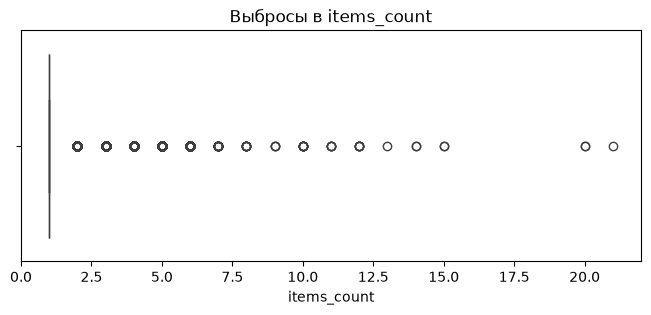

Признак: delivery_time_days
Нижняя граница: -6.66
Верхняя граница: 29.15
Количество выбросов: 4899
Доля выбросов: 4.93%

Самые большие значения:


19590    209.628611
55619    208.351759
61610    195.634016
70307    194.850174
89130    194.633611
Name: delivery_time_days, dtype: float64

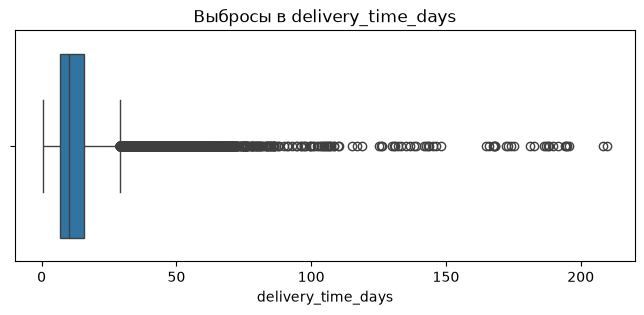

Признак: carrier_handoff_time_days
Нижняя граница: -3.18
Верхняя граница: 7.71
Количество выбросов: 5487
Доля выбросов: 5.52%

Самые большие значения:


36305    125.762569
35213    107.053218
3077     101.361285
44200     64.570208
71854     62.592697
Name: carrier_handoff_time_days, dtype: float64

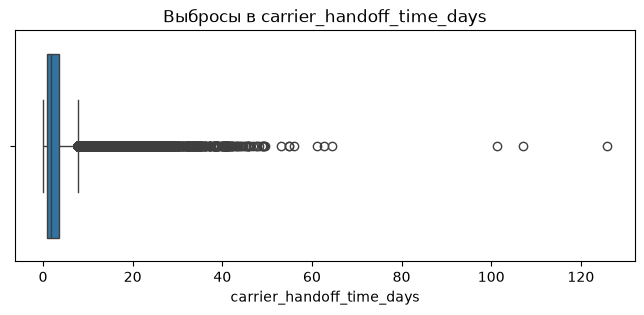

In [214]:
for feature in outlier_features:
    analyze_outliers(orders_analytics,feature)

В рамках анализа выбросов были рассмотрены следующие числовые признаки: `total_price`, `total_freight`, `items_count`, `delivery_time_days`, `carrier_handoff_time_days``.

Для выявления экстремальных значений использовался метод межквартильного размаха (IQR). Были рассчитаны нижняя и верхняя границы допустимых значений, после чего определено количество наблюдений, выходящих за эти пределы.

В результате анализа были обнаружены выбросы во всех рассмотренных признаках:

`total_price` — выявлено около `7.96%` выбросов. Присутствуют заказы с существенно большей стоимостью по сравнению с основной массой наблюдений. Такие значения могут соответствовать реальным крупным заказам, поэтому их автоматическое удаление нецелесообразно.
`total_freight` — около `10%` значений определяются как выбросы. Наблюдаются отдельные заказы с очень высокой стоимостью доставки. Эти значения могут быть связаны с крупногабаритными товарами или удалёнными регионами доставки.
`items_count` — около `9.86%` выбросов. Экстремальные значения представлены заказами с большим количеством товаров. Так как крупные заказы являются допустимым сценарием в электронной коммерции, такие наблюдения требуют дополнительной проверки, а не удаления.
`delivery_time_days` — около `4.93%` выбросов. Обнаружены заказы с очень длительным сроком доставки (до 200+ дней). Такие значения могут быть связаны с проблемами доставки, задержками или особенностями отдельных заказов.
`carrier_handoff_time_days` — около `5.52%` выбросов. Присутствуют случаи длительной передачи заказа перевозчику, которые могут указывать на задержки обработки или логистические особенности.

В целом большинство обнаруженных выбросов находятся в верхней части распределения и связаны с большими значениями стоимости, количества товаров или длительностью доставки. Для данных электронной коммерции такие значения не обязательно являются ошибками, так как могут отражать реальные редкие ситуации.

На этапе EDA было принято решение не удалять выбросы автоматически, так как они могут содержать полезную информацию о нестандартных заказах. Дальнейшая обработка этих значений (например, логарифмическое преобразование, ограничение значений или удаление) должна выполняться только на этапе подготовки данных для моделирования после оценки влияния признаков на целевую переменную.

## 4.21. Анализ финансовой согласованности

In [215]:
orders_analytics["payment_difference"].describe()

count    98665.000000
mean         0.029092
std          1.129221
min        -51.620000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: payment_difference, dtype: float64

In [216]:
orders_analytics["abs_payment_difference"].describe()

count    98665.000000
mean         0.033162
std          1.129109
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: abs_payment_difference, dtype: float64

In [217]:
#количество проблемных заказов
payment_anomalies = orders_analytics[
    orders_analytics["abs_payment_difference"] > 0.01
]

len(payment_anomalies)

381

In [222]:
payment_anomalies.sort_values(
    "abs_payment_difference",
    ascending=False
).head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,delivery_delay_days,is_late_delivery,delay_days,early_delivery_days,bad_review,price_group,multiple_items,weight_group,volume_group,installments_group
11791,ce6d150fb29ada17d2082f4847107665,d8acb46c718975948423dbf1b603b959,delivered,2018-01-25 11:17:02,2018-01-27 12:35:38,2018-01-29 18:32:40,2018-02-21 17:38:51,2018-03-08,3629a4b18f2eb69e03f153158e48d2cc,78580,...,-14.264688,False,0.00000,14.264688,0.0,более 300,False,Q4,Q4,Q4
48686,6e5fe7366a2e1bfbf3257dba0af1267f,5263febf1413e9a60ceb7b842008b7ef,delivered,2016-10-09 22:36:25,2016-10-10 12:02:19,2016-10-14 12:02:21,2016-10-17 13:02:21,2016-12-06,6f90ec5150be36c4475835b5941ab56f,82980,...,-49.456701,False,0.00000,49.456701,1.0,200-300,True,Q4,Q4,Q4
70865,70b742795bc441e94a44a084b6d9ce7a,0c155574f4f4d27594dbdd37731a6ecb,delivered,2017-08-24 10:29:36,2017-08-24 10:35:22,2017-08-30 15:28:21,2017-09-12 20:27:39,2017-09-20,b8b3c435a58aebd788a477bed8342910,95585,...,-7.147465,False,0.00000,7.147465,0.0,более 300,False,Q4,Q4,Q4
33150,996c7e73600ad3723e8627ab7bef81e4,16be3ab0d37467d1f96d6fc30613ee57,delivered,2018-07-16 09:58:16,2018-07-16 10:10:18,2018-07-18 11:01:00,2018-07-20 22:11:39,2018-07-30,99567d452c6589499a2ba8b0fd4658e5,18270,...,-9.075243,False,0.00000,9.075243,0.0,более 300,False,Q4,Q4,Q4
52985,70b7e94ea46d3e8b5bc12a50186edaf0,1c4c6fd6cfc21396ae93680bfc5c34d4,delivered,2018-01-01 13:06:57,2018-01-01 13:17:25,2018-01-03 11:03:40,2018-01-10 00:24:12,2018-02-01,8bd9c53ae5e194fd363ed6714235e6be,33200,...,-21.983194,False,0.00000,21.983194,1.0,200-300,True,Q2,Q2,Q4
85434,bc2c82b0ef78d2252b6176d1972db7c9,81a478af8cea558a5a07090725be2acd,delivered,2017-11-13 21:50:45,2017-11-16 12:56:23,2017-11-17 22:48:34,2017-11-26 18:54:52,2017-12-13,dc813062e0fc23409cd255f7f53c7074,55293,...,-16.211898,False,0.00000,16.211898,0.0,200-300,True,Q2,Q1,Q4
94304,af9ffff2ce6b3defd34fd4c78857a379,c8d062f9057d8290889c432f8985c707,delivered,2018-02-14 13:10:37,2018-02-15 11:30:38,2018-02-16 22:18:55,2018-02-20 14:59:00,2018-03-12,e20f982ec35a961d9e018e56e47e7778,39401,...,-19.375694,False,0.00000,19.375694,0.0,более 300,False,Q1,Q1,Q4
31661,262118ce178bb3e4590a3adcf6d62e6b,2a69da30b726b7f3db7f1059af5d4304,delivered,2016-10-06 14:59:56,2016-10-07 12:13:49,2016-11-17 08:27:59,2016-11-17 16:23:46,2016-11-30,f7b62c75467e8ce080b201667cbbc274,22071,...,-12.316829,False,0.00000,12.316829,1.0,120-200,True,Q4,Q3,Q4
68811,bfdb5bbb06458d600a33d61f5f287472,d82885c55f16d6d73b6cacd3f87bc852,delivered,2018-02-04 21:08:05,2018-02-04 21:29:24,2018-02-07 21:58:31,2018-02-22 21:23:28,2018-03-08,1502940793e8b3ff32e7bd4b231b0eef,64046,...,-13.108704,False,0.00000,13.108704,1.0,более 300,False,Q4,Q4,Q4
8548,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,8c65f37a2cb3d0bedced14e105742bae,delivered,2018-03-19 13:40:14,2018-03-19 13:55:33,2018-03-20 00:28:42,2018-04-10 23:28:27,2018-04-10,b44c3e3d672e8d4fa98b45abb3c38d66,28928,...,0.978090,True,0.97809,0.000000,0.0,200-300,True,Q4,Q4,Q4


In [223]:
payment_anomalies["order_status"].value_counts()

order_status
delivered    375
shipped        3
canceled       2
invoiced       1
Name: count, dtype: int64

In [224]:
payment_anomalies["main_payment_type"].value_counts()

main_payment_type
credit_card    339
boleto          26
debit_card       9
voucher          7
Name: count, dtype: int64

In [225]:
payment_anomalies["max_installments"].describe()

count    381.000000
mean       5.464567
std        3.675943
min        1.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       24.000000
Name: max_installments, dtype: float64

In [226]:
payment_anomalies["bad_review"].mean()

np.float64(0.2328042328042328)

In [227]:
orders_analytics["bad_review"].mean()

np.float64(0.1468892199487195)

В ходе анализа признака `payment_difference` было установлено, что в большинстве заказов расхождение между ожидаемой и фактической суммой платежа отсутствует. Медианное значение payment_difference равно 0, а 75% заказов также имеют нулевое отклонение. Это говорит о высокой согласованности финансовых данных.

Для поиска потенциальных аномалий был использован абсолютный размер отклонения `abs_payment_difference`. Заказы с отклонением более 0.01 были выделены как проблемные. Таких заказов оказалось `381`, что составляет менее 0.4% от общего количества наблюдений (98 665 заказов).

Дополнительный анализ этих случаев показал, что:

большинство аномальных заказов имеют статус `delivered` (375 из 381), поэтому расхождения не связаны преимущественно с отмененными или незавершенными заказами;
среди способов оплаты преобладает `credit_card` (339 случаев), что соответствует общей распространенности данного способа оплаты;
среднее количество платежных частей (`max_installments`) среди аномальных заказов составляет около `5.5`, при этом значения находятся в диапазоне от 1 до 24;
доля негативных отзывов (`bad_review`) среди заказов с финансовыми расхождениями составляет около `23.3%`, что выше общей доли негативных отзывов в датасете (14.7%).

Таким образом, обнаруженные расхождения являются редкими случаями и не указывают на систематическую проблему качества данных. Однако небольшое повышение доли негативных отзывов среди таких заказов может свидетельствовать о возможной связи финансовых несоответствий с ухудшением пользовательского опыта. В дальнейшем эти наблюдения могут быть дополнительно изучены при построении моделей или анализе факторов, влияющих на негативные отзывы.

## 4.22. Анализ признаков, связанных с отзывами

In [ ]:
#Пользователи с плохими оценками чаще оставляют текстовый комментарий?
pd.crosstab(
    orders_analytics["has_review_comment"],
    orders_analytics["bad_review"],
    normalize="columns"
)

bad_review,0.0,1.0
has_review_comment,,
0.0,0.644686,0.252242
1.0,0.355314,0.747758


In [ ]:
#Оставляют ли недовольные пользователи чаще заголовок?
pd.crosstab(
    orders_analytics["has_review_title"],
    orders_analytics["bad_review"],
    normalize="columns"
)

bad_review,0.0,1.0
has_review_title,,
0.0,0.890721,0.837933
1.0,0.109279,0.162067


In [233]:
orders_analytics.groupby("bad_review")["reviews_count"].describe()

,count,mean,std,min,25%,50%,75%,max
bad_review,,,,,,,,
0.0,84179.0,1.00537,0.073566,1.0,1.0,1.0,1.0,3.0
1.0,14494.0,1.00683,0.083200,1.0,1.0,1.0,1.0,3.0


In [234]:
#Склонны ли недовольные пользователи оставлять несколько отзывов?
pd.crosstab(
    orders_analytics["had_multiple_reviews"],
    orders_analytics["bad_review"],
    normalize="columns"
)

bad_review,0.0,1.0
had_multiple_reviews,,
0.0,0.994666,0.993239
1.0,0.005334,0.006761


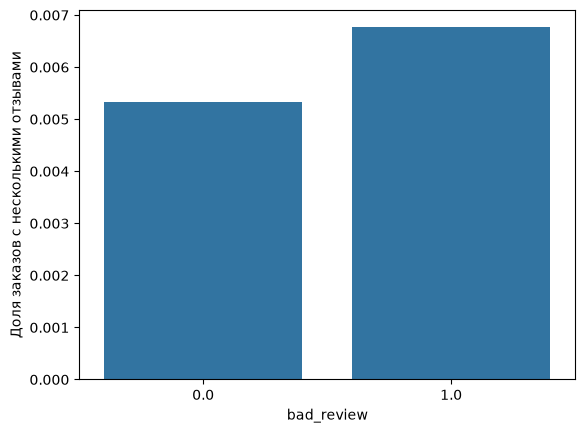

In [236]:
sns.barplot(
    data=orders_analytics,
    x="bad_review",
    y="had_multiple_reviews",
    errorbar=None
)

plt.ylabel("Доля заказов с несколькими отзывами")
plt.xlabel("bad_review")
plt.show()

По результатам анализа признаков, связанных с отзывами, можно сделать следующие выводы.

Была исследована зависимость между наличием текстового комментария, заголовка отзыва, количеством отзывов и целевой переменной bad_review.

Анализ показал, что пользователи с негативной оценкой значительно чаще оставляют текстовые комментарии. Среди заказов с плохим отзывом доля пользователей, оставивших комментарий, составляет около 74,8%, тогда как среди хороших отзывов этот показатель равен примерно 35,5%. Это говорит о том, что наличие комментария является сильным поведенческим признаком, связанным с негативным пользовательским опытом.

Аналогичная зависимость наблюдается для наличия заголовка отзыва. Пользователи с плохими отзывами чаще добавляют заголовок: около 16,2% негативных отзывов содержат заголовок против примерно 10,9% среди положительных отзывов. Однако различие менее выражено по сравнению с текстовыми комментариями.

При анализе количества отзывов (reviews_count) существенных отличий между группами не обнаружено. В обеих группах медианное и типичное значение признака равно 1, а средние значения практически совпадают:

хорошие отзывы: 1.005;
плохие отзывы: 1.007.

Также был исследован признак наличия нескольких отзывов (had_multiple_reviews). Доля заказов с несколькими отзывами очень мала в обеих группах:

хорошие отзывы — около 0,53%;
плохие отзывы — около 0,68%.

Таким образом, наличие нескольких отзывов практически не связано с негативной оценкой и не является информативным признаком.

В результате анализа можно сделать вывод, что наиболее выраженную связь с негативным отзывом имеют признаки, характеризующие активность пользователя при написании отзыва (has_review_comment, в меньшей степени has_review_title). При этом данные признаки появляются уже после завершения заказа и написания отзыва, поэтому их использование в модели для предварительного прогнозирования плохого отзыва может привести к утечке целевой переменной. 

## 4.23. Анализ повторных покупателей

In [237]:
customer_unique_orders = orders_analytics.groupby("customer_unique_id").agg(
    num_of_orders = ("order_id", "size"),
    bad_review_rate = ("bad_review", "mean")
)

customer_unique_orders["bad_review_rate"] *= 100

customer_unique_orders

,num_of_orders,bad_review_rate
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,0.0
0000f46a3911fa3c0805444483337064,1,0.0
0000f6ccb0745a6a4b88665a16c9f078,1,0.0
0004aac84e0df4da2b147fca70cf8255,1,0.0
...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,1,0.0
fffea47cd6d3cc0a88bd621562a9d061,1,0.0
ffff371b4d645b6ecea244b27531430a,1,0.0


In [241]:
#сколько всего клиентов?
len(customer_unique_orders)

96096

In [240]:
#сколько клиентов сделали один заказ?
len(customer_unique_orders[customer_unique_orders["num_of_orders"] == 1])

93099

In [242]:
#сколько клиентов сделали несколько заказов?
len(customer_unique_orders[customer_unique_orders["num_of_orders"] > 1])

2997

In [243]:
customer_unique_orders["num_of_orders"].value_counts()

num_of_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [244]:
new_customers = customer_unique_orders[customer_unique_orders["num_of_orders"] == 1]
repeat_customers = customer_unique_orders[customer_unique_orders["num_of_orders"] > 1]

In [246]:
#доля повторных клиентов
repeat_rate = (
    (customer_unique_orders["num_of_orders"] > 1)
    .mean()
    * 100
)

repeat_rate

np.float64(3.1187562437562435)

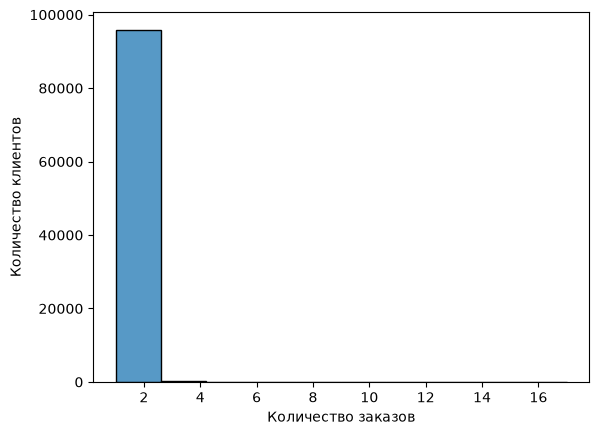

In [247]:
sns.histplot(
    customer_unique_orders["num_of_orders"],
    bins=10
)

plt.xlabel("Количество заказов")
plt.ylabel("Количество клиентов")
plt.show()

In [249]:
customer_unique_orders.groupby(
    customer_unique_orders["num_of_orders"] > 1
)["bad_review_rate"].mean()

num_of_orders
False    14.712313
True     14.656885
Name: bad_review_rate, dtype: float64

В ходе анализа повторных покупателей было выявлено, что большинство клиентов совершили только один заказ — 93 099 клиентов, тогда как повторные покупки совершили 2 997 клиентов (около 3,12% от общего числа покупателей). Максимальное количество заказов у одного клиента достигало 17, однако такие случаи являются единичными.

Распределение количества заказов показывает, что основная масса клиентов не возвращается за повторной покупкой, поэтому доля постоянных покупателей относительно невелика.

При сравнении уровня плохих отзывов между новыми и повторными клиентами существенной разницы обнаружено не было: средняя доля негативных отзывов составляет около 14,7% для обеих групп. Это говорит о том, что факт повторной покупки не имеет заметной связи с вероятностью получения негативного отзыва.

## 4.24. Финальные выводы для моделирования

В качестве целевой переменной выбран признак `bad_review`, который является бинарным и имеет выраженный дисбаланс классов: около 14,7% заказов относятся к негативным отзывам, а около 85,3% — к положительным. При построении модели необходимо учитывать дисбаланс классов и использовать соответствующие метрики оценки качества (например, ROC-AUC, PR-AUC, F1-score, recall), а не только accuracy.

Наиболее перспективными признаками для модели являются характеристики, связанные с процессом доставки. Анализ показал, что наличие и величина опоздания (is_late, delay_days, delay_group) имеют наиболее сильную связь с вероятностью негативного отзыва. Вероятность плохого отзыва значительно увеличивается при росте времени задержки доставки, поэтому данные признаки должны иметь высокий приоритет при построении модели.

Также информативными могут быть признаки, связанные со структурой и сложностью заказа:

количество товаров в заказе;
количество продавцов;
количество категорий;
вес и объём заказа.

Было выявлено, что более сложные заказы чаще связаны с негативными отзывами, поэтому признаки, описывающие состав заказа, могут улучшить предсказательную способность модели.

Финансовые характеристики (order_total, total_price, total_freight, freight_ratio) также имеют некоторую связь с целевой переменной: более дорогие и крупные заказы чаще сопровождаются негативными отзывами. Однако влияние этих признаков слабее, чем у характеристик доставки.

Платёжные признаки в большинстве случаев показали слабую связь с bad_review. Их можно оставить в модели как дополнительные признаки, но не стоит ожидать от них значительного вклада.

Временные признаки оформления заказа (день недели, час покупки, месяц) практически не показали зависимости с негативными отзывами, поэтому их влияние, вероятно, будет ограниченным. Их можно использовать только после дополнительного преобразования или в комбинации с другими признаками.

Признаки, связанные с отзывами (has_review_comment, has_review_title, reviews_count, had_multiple_reviews) хорошо объясняют уже сформированный отзыв, однако для модели, которая должна прогнозировать вероятность плохого отзыва до его появления, использовать их нельзя, так как они являются потенциальной утечкой целевой информации (data leakage).

Также были выявлены выбросы в ряде числовых признаков (total_price, total_freight, delivery_time_days, carrier_handoff_time_days и др.). Они отражают реальные экстремальные случаи, поэтому перед обучением модели необходимо аккуратно решить вопрос их обработки: использовать логарифмические преобразования, робастное масштабирование или модели, устойчивые к выбросам, вместо простого удаления.

Признаки финансовой согласованности (payment_difference) показали, что большинство заказов имеют корректное совпадение сумм оплаты, поэтому данный признак не является ключевым, но может использоваться для выявления редких аномальных случаев.

В результате для моделирования рекомендуется сформировать набор признаков, включающий:

характеристики доставки (`delivery_time_days`, `delay_days`, `is_late`);
характеристики заказа (`order_total`, `items_count`, количество продавцов и категорий);
физические параметры (`weight`, `volume`);
географические признаки (customer_state, признаки региона);
платёжные признаки в ограниченном количестве.

При этом необходимо исключить признаки, которые появляются только после получения отзыва, чтобы модель могла корректно решать задачу предварительного прогнозирования негативного опыта клиента.